US Accidents (2016-2023)
This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. The dataset currently contains approximately 7.7 million accident records. For more information about this dataset, please visit here.

In [1]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.cluster import MiniBatchKMeans
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.utils import resample
import seaborn as sns

In [2]:
df_new = pd.read_csv("/kaggle/input/notebooks/marwaashraf5814/full-ver/Clean_Version_Accident.csv")
print(df_new.head(5))

   Unnamed: 0  Severity  Start_Lat  Start_Lng  Distance(mi)          City  \
0           0         3  39.865147 -84.058723          0.01        Dayton   
1           1         2  39.928059 -82.831184          0.01  Reynoldsburg   
2           2         2  39.063148 -84.032608          0.01  Williamsburg   
3           3         3  39.747753 -84.205582          0.01        Dayton   
4           4         2  39.627781 -84.188354          0.01        Dayton   

       County State    Timezone  Temperature(F)  ...  Hour_Start  \
0  Montgomery    OH  US/Eastern            36.9  ...           5   
1    Franklin    OH  US/Eastern            37.9  ...           6   
2    Clermont    OH  US/Eastern            36.0  ...           6   
3  Montgomery    OH  US/Eastern            35.1  ...           7   
4  Montgomery    OH  US/Eastern            36.0  ...           7   

   Minutes_Start  Hour_End  Minutes_End Day_of_Week  Month  Year  \
0             46        11            0           0      2  

In [3]:
df_encode=df_new.copy()

In [4]:
#Encode Day and Night Columns
d_n_col=["Civil_Twilight","Sunrise_Sunset","Nautical_Twilight","Astronomical_Twilight"]
df_encode[d_n_col] = df_encode[d_n_col].apply(lambda x: x.map({"Night":1, "Day":0}))

In [5]:
df_encode.head(5)

,Unnamed: 0,Severity,Start_Lat,Start_Lng,Distance(mi),City,County,State,Timezone,Temperature(F),...,Hour_Start,Minutes_Start,Hour_End,Minutes_End,Day_of_Week,Month,Year,Duration_Hours,Duration_Minutes,Rush_Hour
0,0,3,39.865147,-84.058723,0.01,Dayton,Montgomery,OH,US/Eastern,36.9,...,5,46,11,0,0,2,2016,5.23,314.0,0
1,1,2,39.928059,-82.831184,0.01,Reynoldsburg,Franklin,OH,US/Eastern,37.9,...,6,7,6,37,0,2,2016,0.50,30.0,0
2,2,2,39.063148,-84.032608,0.01,Williamsburg,Clermont,OH,US/Eastern,36.0,...,6,49,7,19,0,2,2016,0.50,30.0,0
3,3,3,39.747753,-84.205582,0.01,Dayton,Montgomery,OH,US/Eastern,35.1,...,7,23,7,53,0,2,2016,0.50,30.0,1
4,4,2,39.627781,-84.188354,0.01,Dayton,Montgomery,OH,US/Eastern,36.0,...,7,39,8,9,0,2,2016,0.50,30.0,1


In [6]:
#Encode True ansd False 
T_F=["Amenity","Bump","Crossing","Give_Way","Junction","No_Exit","Railway","Roundabout","Station","Stop","Traffic_Calming","Traffic_Signal","Turning_Loop"]
df_encode[T_F] = df_encode[T_F].astype(int)

In [7]:
df_encode.head(5)

,Unnamed: 0,Severity,Start_Lat,Start_Lng,Distance(mi),City,County,State,Timezone,Temperature(F),...,Hour_Start,Minutes_Start,Hour_End,Minutes_End,Day_of_Week,Month,Year,Duration_Hours,Duration_Minutes,Rush_Hour
0,0,3,39.865147,-84.058723,0.01,Dayton,Montgomery,OH,US/Eastern,36.9,...,5,46,11,0,0,2,2016,5.23,314.0,0
1,1,2,39.928059,-82.831184,0.01,Reynoldsburg,Franklin,OH,US/Eastern,37.9,...,6,7,6,37,0,2,2016,0.50,30.0,0
2,2,2,39.063148,-84.032608,0.01,Williamsburg,Clermont,OH,US/Eastern,36.0,...,6,49,7,19,0,2,2016,0.50,30.0,0
3,3,3,39.747753,-84.205582,0.01,Dayton,Montgomery,OH,US/Eastern,35.1,...,7,23,7,53,0,2,2016,0.50,30.0,1
4,4,2,39.627781,-84.188354,0.01,Dayton,Montgomery,OH,US/Eastern,36.0,...,7,39,8,9,0,2,2016,0.50,30.0,1


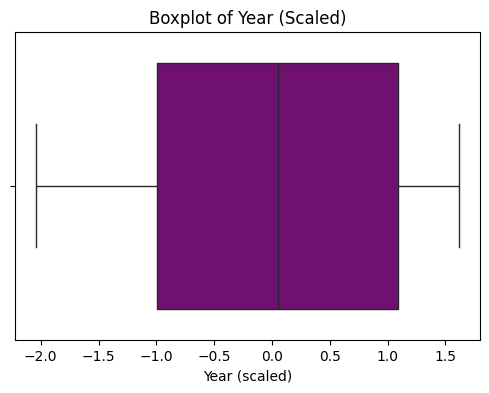

In [57]:
scaler = StandardScaler()

df_encode['Year_scaled'] = scaler.fit_transform(df_encode[['Year']])
plt.figure(figsize=(6,4))
sns.boxplot(x=df_encode['Year_scaled'], color='purple')
plt.title("Boxplot of Year (Scaled)")
plt.xlabel("Year (scaled)")
plt.show()

In [8]:
#Drop Columns 
cols_to_drop = [
    'Unnamed: 0','County','State','Timezone',
]
df_encode = df_encode.drop(columns=cols_to_drop, errors='ignore')
print("Remaining Data columns:", df_encode.columns)
print("Train shape:", df_encode.shape)

Remaining Data columns: Index(['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'City',
       'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Hour_Start', 'Minutes_Start', 'Hour_End',
       'Minutes_End', 'Day_of_Week', 'Month', 'Year', 'Duration_Hours',
       'Duration_Minutes', 'Rush_Hour'],
      dtype='object')
Train shape: (7728394, 41)


In [9]:
df_encode.head(5)

,Severity,Start_Lat,Start_Lng,Distance(mi),City,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),...,Hour_Start,Minutes_Start,Hour_End,Minutes_End,Day_of_Week,Month,Year,Duration_Hours,Duration_Minutes,Rush_Hour
0,3,39.865147,-84.058723,0.01,Dayton,36.9,31.401920,91.0,29.68,10.0,...,5,46,11,0,0,2,2016,5.23,314.0,0
1,2,39.928059,-82.831184,0.01,Reynoldsburg,37.9,32.607069,100.0,29.65,10.0,...,6,7,6,37,0,2,2016,0.50,30.0,0
2,2,39.063148,-84.032608,0.01,Williamsburg,36.0,33.300000,100.0,29.67,10.0,...,6,49,7,19,0,2,2016,0.50,30.0,0
3,3,39.747753,-84.205582,0.01,Dayton,35.1,31.000000,96.0,29.64,9.0,...,7,23,7,53,0,2,2016,0.50,30.0,1
4,2,39.627781,-84.188354,0.01,Dayton,36.0,33.300000,89.0,29.65,6.0,...,7,39,8,9,0,2,2016,0.50,30.0,1


**Try to Downsample Data Becouse the Class 2 make data more imbalanced So we need to use a technique to make data more reliable after resample**

✅ Train/Test split
✅ Cyclical time encoding
✅ Target encoding (City, Wind, Weather)
✅ Correlation matrix after target encoding
✅ Downsampling
✅ Scaling
✅ XGBoost
✅ Feature importance

In [11]:
# 2. Config
# ============================================
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = "Severity"
CAT_COLS = ['City', 'Wind_Direction', 'Weather_Condition']
N_CLUSTERS = 50  # number of clusters per class for downsampling

In [12]:
# 3. Feature Engineering
# ============================================
def add_cyclical_features(df_encode):
    df_encode['Hour_Start_sin'] = np.sin(2*np.pi*df_encode['Hour_Start']/24)
    df_encode['Hour_Start_cos'] = np.cos(2*np.pi*df_encode['Hour_Start']/24)

    df_encode['Hour_End_sin'] = np.sin(2*np.pi*df_encode['Hour_End']/24)
    df_encode['Hour_End_cos'] = np.cos(2*np.pi*df_encode['Hour_End']/24)

    df_encode['Minutes_Start_sin'] = np.sin(2*np.pi*df_encode['Minutes_Start']/60)
    df_encode['Minutes_Start_cos'] = np.cos(2*np.pi*df_encode['Minutes_Start']/60)

    df_encode['Minutes_End_sin'] = np.sin(2*np.pi*df_encode['Minutes_End']/60)
    df_encode['Minutes_End_cos'] = np.cos(2*np.pi*df_encode['Minutes_End']/60)

    df_encode['Day_sin'] = np.sin(2*np.pi*df_encode['Day_of_Week']/7)
    df_encode['Day_cos'] = np.cos(2*np.pi*df_encode['Day_of_Week']/7)

    df_encode['Month_sin'] = np.sin(2*np.pi*df_encode['Month']/12)
    df_encode['Month_cos'] = np.cos(2*np.pi*df_encode['Month']/12)

    df_encode.drop([
        'Hour_Start','Hour_End',
        'Minutes_Start','Minutes_End',
        'Day_of_Week','Month'
    ], axis=1, inplace=True, errors="ignore")

    return df_encode

In [13]:
# 5. Train/Test Split
# ============================================
X = df_encode.drop(TARGET_COL, axis=1)
y = df_encode[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

X_train = add_cyclical_features(X_train)
X_test = add_cyclical_features(X_test)

In [14]:
# 4. Merge for behavior downsampling
# =====================================================
train_df = X_train.copy()
train_df[TARGET_COL] = y_train

In [15]:
# Separate class 2
class2 = train_df[train_df[TARGET_COL] == 2]
others = train_df[train_df[TARGET_COL] != 2]

In [17]:
# -----------------------------
# 1. Define behavior columns
# -----------------------------
behavior_cols = list(class2.select_dtypes(include=np.number).columns) + ['Wind_Direction', 'Weather_Condition']

# -----------------------------
# 2. Convert categoricals efficiently
# -----------------------------
behavior = class2[behavior_cols].copy()
for col in behavior.columns:
    if behavior[col].dtype == 'object':
        behavior[col] = behavior[col].astype('category')
    else:
        # Optional: round numeric columns to reduce unique hashes (memory optimization)
        behavior[col] = behavior[col].round(4)

# -----------------------------
# 3. Compute hash per row
# -----------------------------
# Use only numeric codes for categoricals (saves memory)
for col in behavior.select_dtypes('category'):
    behavior[col] = behavior[col].cat.codes

# Now compute a single hash per row using tuples
hashes = pd.util.hash_pandas_object(behavior, index=False)
class2['hash'] = hashes

# -----------------------------
# 4. Drop duplicates by hash
# -----------------------------
class2_down = class2.drop_duplicates('hash').drop('hash', axis=1)

# -----------------------------
# 5. Optional: cap maximum size
# -----------------------------
MAX_CLASS2 = 200_000
if len(class2_down) > MAX_CLASS2:
    class2_down = class2_down.sample(MAX_CLASS2, random_state=42)

# -----------------------------
# 6. Merge back with other classes
# -----------------------------
train_down = pd.concat([class2_down, others])

# -----------------------------
# 7. Print class counts
# -----------------------------
print("Class counts after downsampling:")
print(train_down[TARGET_COL].value_counts())

/tmp/ipykernel_166/1656690310.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  class2['hash'] = hashes


Class counts after downsampling:
Severity
3    1039469
2     200000
4     163768
1      53893
Name: count, dtype: int64


In [18]:
# 6. Return target
# =====================================================
X_train = train_down.drop(TARGET_COL, axis=1)
y_train = train_down[TARGET_COL]

In [19]:
# 7. Target Encoding for CAT_COLS
# =====================================================
encoder = TargetEncoder(cols=CAT_COLS)

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc  = encoder.transform(X_test)

In [20]:
# 8. Scaling
# =====================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

In [28]:
# 6. Class weights and sample weights
# ==============================
class_weights = {1:2, 2:1, 3:5, 4:8}
sample_weights = y_train.map(class_weights)

# ==============================
# 7. One-vs-Rest XGBoost
# ==============================
set_config(enable_metadata_routing=True)  # allow sample_weight

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.set_fit_request(sample_weight=True)
model = OneVsRestClassifier(xgb)
model.fit(X_train_scaled, y_train, sample_weight=sample_weights)


OneVsRestClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='mlogloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=8,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=-1,
                                            num_parallel_tree=None, ...))

In [29]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.55      0.69      0.61     13473
           2       1.00      0.28      0.44   1231396
           3       0.31      0.97      0.47    259868
           4       0.09      0.80      0.16     40942

    accuracy                           0.41   1545679
   macro avg       0.49      0.68      0.42   1545679
weighted avg       0.85      0.41      0.44   1545679



In [30]:
# Get predicted probabilities
y_pred_proba = model.predict_proba(X_test_scaled)

# Set per-class thresholds (instead of argmax)
thresholds = {1:0.5, 2:0.5, 3:0.5, 4:0.5}  # you can tune these
y_pred_custom = []
for probs in y_pred_proba:
    assigned = [cls for i, cls in enumerate(sorted(thresholds.keys())) if probs[i] >= thresholds[cls]]
    if len(assigned)==0:
        assigned = [2]  # fallback to majority class
    # if multiple classes pass threshold, choose highest probability
    y_pred_custom.append(assigned[np.argmax([probs[i-1] for i in assigned])])

y_pred_custom = np.array(y_pred_custom)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           1       0.60      0.66      0.63     13473
           2       0.99      0.32      0.48   1231396
           3       0.32      0.96      0.48    259868
           4       0.09      0.79      0.17     40942

    accuracy                           0.44   1545679
   macro avg       0.50      0.68      0.44   1545679
weighted avg       0.85      0.44      0.48   1545679



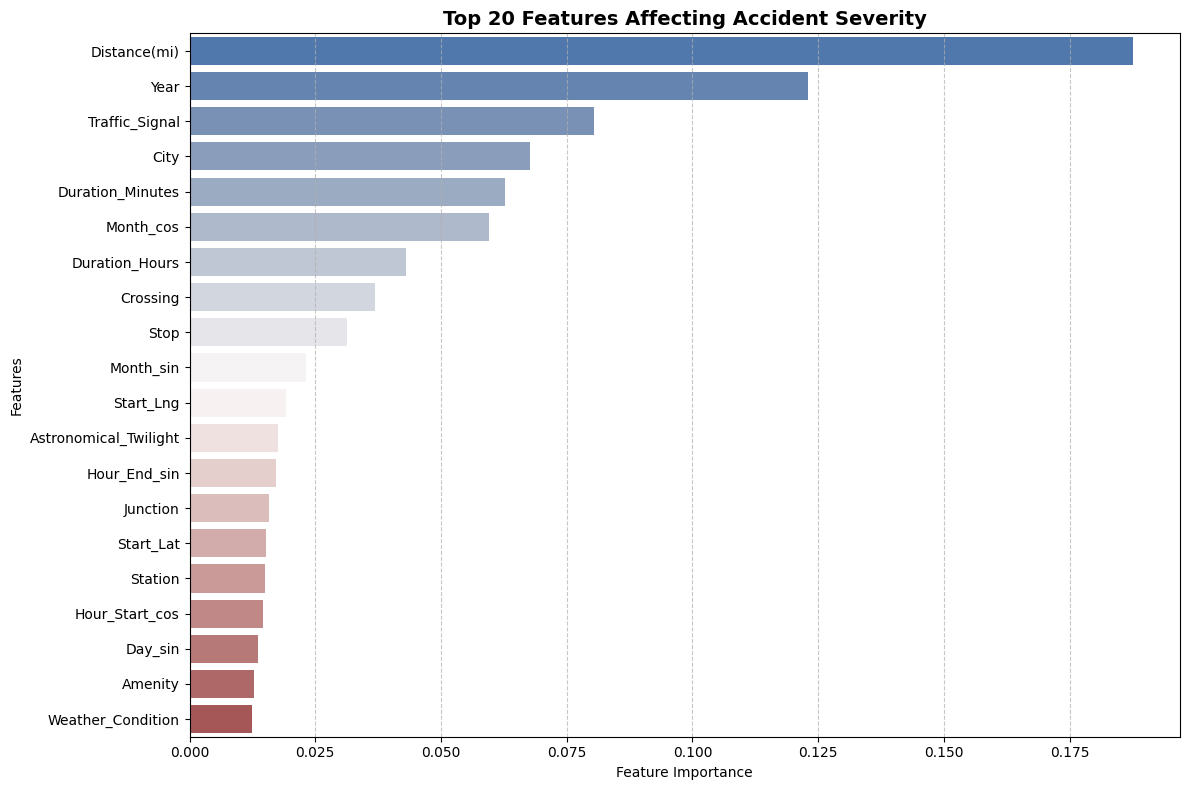

In [31]:
# 12. Feature Importance
# =====================================================
# Average importance over OVR models
importances = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)

feature_importance = pd.DataFrame({
    'Feature': X_train_enc.columns,
    'Coefficient': importances,
    'Abs_Coefficient': np.abs(importances)
})

feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)


# =====================================================
# 13. Plot Feature Importance
# =====================================================
plt.figure(figsize=(12,8))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance.head(20),
    palette='vlag',
    hue='Feature',
    legend=False
)

plt.title(
    'Top 20 Features Affecting Accident Severity',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [40]:
# 1. Shift target labels to start from 0 and ensure int type
y_train_shift = (y_train - 1).astype(int)
y_test_shift  = (y_test - 1).astype(int)

# 2. Adjust class weights keys to match shifted labels
class_weights = {0:3, 1:3, 2:5, 3:10}  # shifted labels
sample_weights = y_train_shift.map(class_weights).to_numpy()  # convert to numpy array

# 3. Define XGBoost classifier (native multiclass)
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,  # classes 0,1,2,3
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# 4. Fit the model with shifted labels
xgb.fit(X_train_scaled, y_train_shift, sample_weight=sample_weights)

# 5. Predict on test set
y_pred_shift = xgb.predict(X_test_scaled)

# 6. Shift predictions back to original labels (1,2,3,4)
y_pred = y_pred_shift + 1

In [41]:
y_proba = xgb.predict_proba(X_test_scaled)
classes = sorted(y_test.unique())

# Thresholds (example, tune with validation)
thresholds = {1:0.5, 2:0.3, 3:0.5, 4:0.7}  

y_pred_custom = []
for probs in y_proba:
    assigned = [cls for i, cls in enumerate(classes) if probs[i] >= thresholds[cls]]
    if len(assigned)==0:
        assigned = [2]  # fallback to majority
    y_pred_custom.append(assigned[np.argmax([probs[i-1] for i in assigned])])
y_pred_custom = np.array(y_pred_custom)

=== Classification Report ===
              precision    recall  f1-score   support

           1       0.59      0.72      0.65     13473
           2       0.97      0.57      0.72   1231396
           3       0.37      0.94      0.53    259868
           4       0.18      0.61      0.28     40942

    accuracy                           0.64   1545679
   macro avg       0.53      0.71      0.54   1545679
weighted avg       0.84      0.64      0.67   1545679



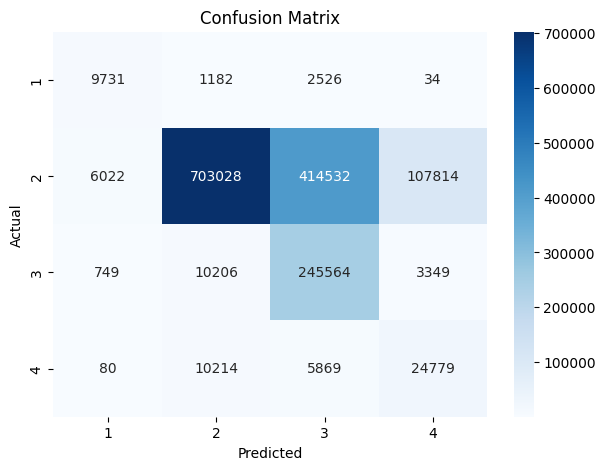

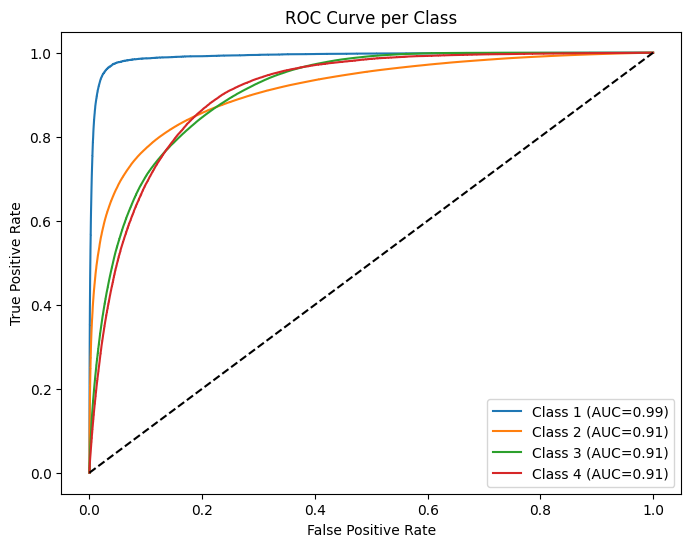

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


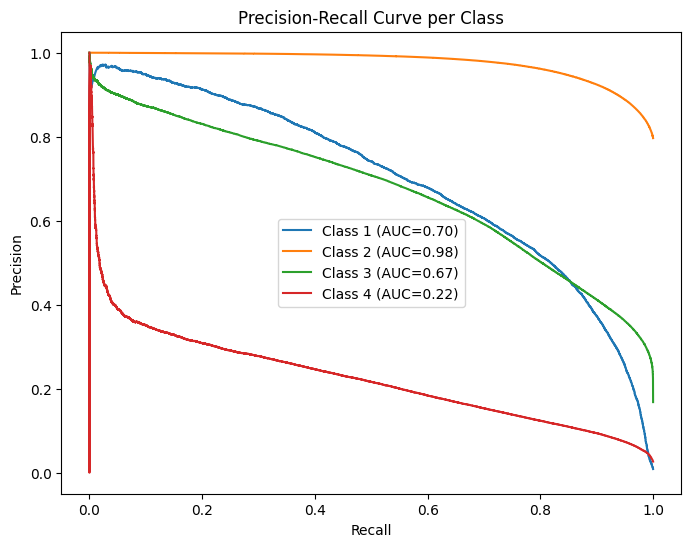

In [43]:


# 3. Classification report as heatmap
# -----------------------------
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_custom))

# -----------------------------
# 4. Confusion matrix heatmap
# -----------------------------
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# -----------------------------
# 5. ROC curves per class
# -----------------------------
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve((y_test==cls).astype(int), y_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# -----------------------------
# 6. Precision-Recall curves per class
# -----------------------------
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve((y_test==cls).astype(int), y_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {cls} (AUC={pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()

In [45]:
# Shifted labels (0-based)
y_train_shift = (y_train - 1).astype(int)

# Tune class weights
class_weights = {0:2, 1:5, 2:3, 3:10}  # 1=Class2, 3=Class4 (shifted labels)
sample_weights = y_train_shift.map(class_weights).to_numpy()

In [46]:
y_proba = xgb.predict_proba(X_test_scaled)
classes = sorted(y_test.unique())  # [1,2,3,4]

# Example thresholds (tune with validation set)
thresholds = {1:0.3, 2:0.3, 3:0.5, 4:0.7}  

y_pred_custom = []
for probs in y_proba:
    assigned = [cls for i, cls in enumerate(classes) if probs[i] >= thresholds[cls]]
    if len(assigned)==0:
        assigned = [2]  # fallback to majority class
    chosen_class = assigned[np.argmax([probs[i-1] for i in assigned])]
    y_pred_custom.append(chosen_class)

y_pred_custom = np.array(y_pred_custom)

=== Classification Report ===
              precision    recall  f1-score   support

           1       0.50      0.78      0.61     13473
           2       0.97      0.57      0.72   1231396
           3       0.37      0.94      0.53    259868
           4       0.18      0.61      0.28     40942

    accuracy                           0.63   1545679
   macro avg       0.51      0.73      0.53   1545679
weighted avg       0.85      0.63      0.67   1545679



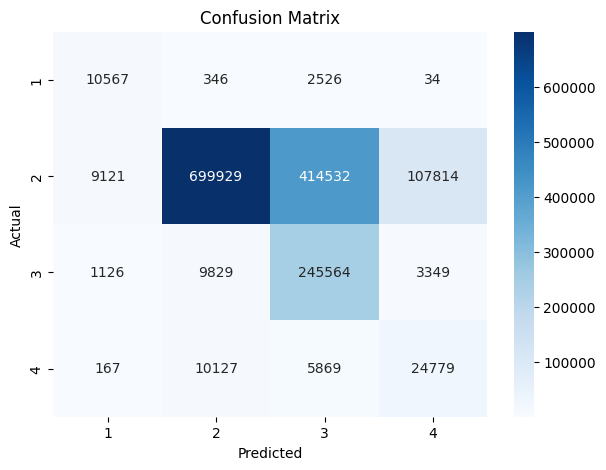

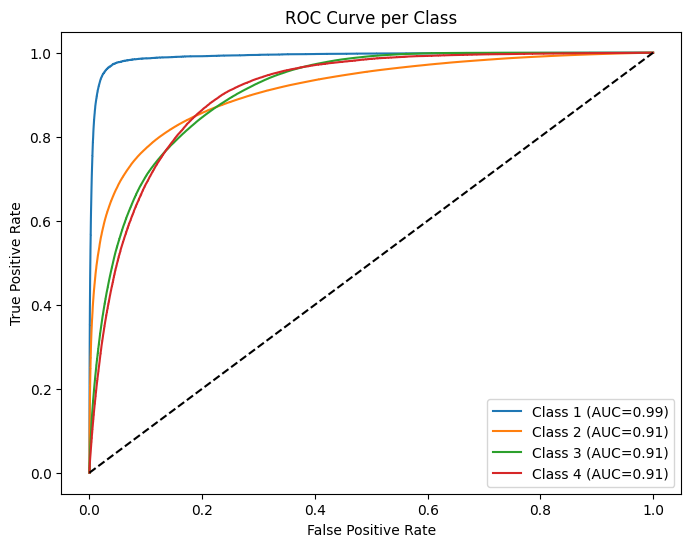

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


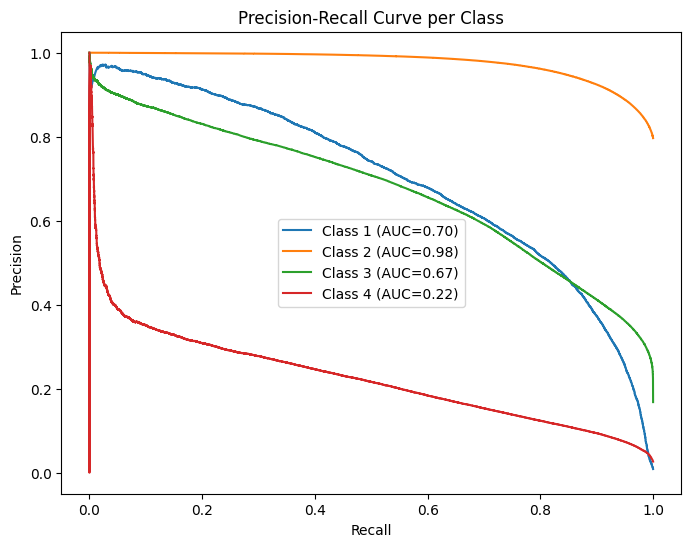

In [47]:
# 3. Classification report as heatmap
# -----------------------------
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_custom))

# -----------------------------
# 4. Confusion matrix heatmap
# -----------------------------
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# -----------------------------
# 5. ROC curves per class
# -----------------------------
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve((y_test==cls).astype(int), y_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# -----------------------------
# 6. Precision-Recall curves per class
# -----------------------------
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve((y_test==cls).astype(int), y_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {cls} (AUC={pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()

In [52]:

# Oversample Class 4
class4 = train_down[train_down[TARGET_COL]==4]
class4_upsampled = resample(class4,
                            replace=True,
                            n_samples=200_000,
                            random_state=42)
train_balanced = pd.concat([train_down[train_down[TARGET_COL]!=4], class4_upsampled])

In [53]:
# 6. Train-test split
# ==============================
X = train_balanced.drop(TARGET_COL, axis=1)
y = train_balanced[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [54]:
# 7. Identify categorical and numeric
# ==============================
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

In [55]:
# 8. Target encoding for categorical
# ==============================
if len(cat_cols) > 0:
    te = TargetEncoder(cols=cat_cols)
    X_train[cat_cols] = te.fit_transform(X_train[cat_cols], y_train)
    X_test[cat_cols] = te.transform(X_test[cat_cols])


In [56]:
# 9. Standard scaling for numeric
# ==============================
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [57]:
# 10. Shift labels to 0-based for XGBoost
# ==============================
y_train_shift = (y_train - 1).astype(int)
y_test_shift  = (y_test - 1).astype(int)


In [58]:
# 11. Sample weights (optional, can fine-tune for Class 2 & 4)
# ==============================
class_weights = {0:2, 1:3, 2:3, 3:10}  # 0=Class1, 1=Class2, 2=Class3, 3=Class4
sample_weights = y_train_shift.map(class_weights).to_numpy()

In [59]:
# 12. Train native multiclass XGBoost
# ==============================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train_shift, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=4, ...)

In [60]:
# ==============================
# 13. Predict with thresholds
# ==============================
y_proba = xgb.predict_proba(X_test)
classes = sorted(y_test.unique())  # [1,2,3,4]

# Probability thresholds (tune to boost Class2 recall & Class4 precision)
#thresholds = {1:0.3, 2:0.3, 3:0.5, 4:0.7}
thresholds = {
    1:0.6,
    2:0.1,
    3:0.5,
    4:0.7
}
# y_pred_custom = []
# for probs in y_proba:
#     assigned = [cls for i, cls in enumerate(classes) if probs[i] >= thresholds[cls]]
#     if len(assigned) == 0:
#         assigned = [2]  # fallback to majority
#     chosen_class = assigned[np.argmax([probs[i-1] for i in assigned])]
#     y_pred_custom.append(chosen_class)

# y_pred_custom = np.array(y_pred_custom)

y_pred_custom = []

for probs in y_proba:

    assigned = [cls for i, cls in enumerate(classes) 
                if probs[i] >= thresholds[cls]]

    # FIX: no cheating fallback
    if len(assigned) == 0:
        chosen_class = classes[np.argmax(probs)]
    else:
        chosen_class = assigned[
            np.argmax([probs[classes.index(i)] for i in assigned])
        ]

    y_pred_custom.append(chosen_class)

y_pred_custom = np.array(y_pred_custom)

=== Classification Report ===
              precision    recall  f1-score   support

           1       0.88      0.79      0.83     10779
           2       0.76      1.00      0.86     40000
           3       0.97      0.92      0.95    207894
           4       0.83      0.81      0.82     40000

    accuracy                           0.91    298673
   macro avg       0.86      0.88      0.87    298673
weighted avg       0.92      0.91      0.92    298673



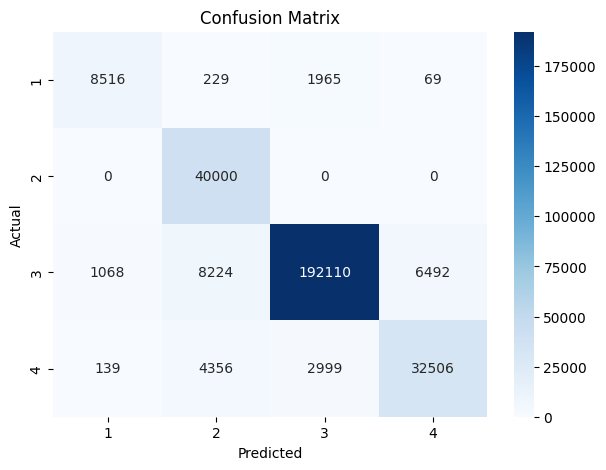

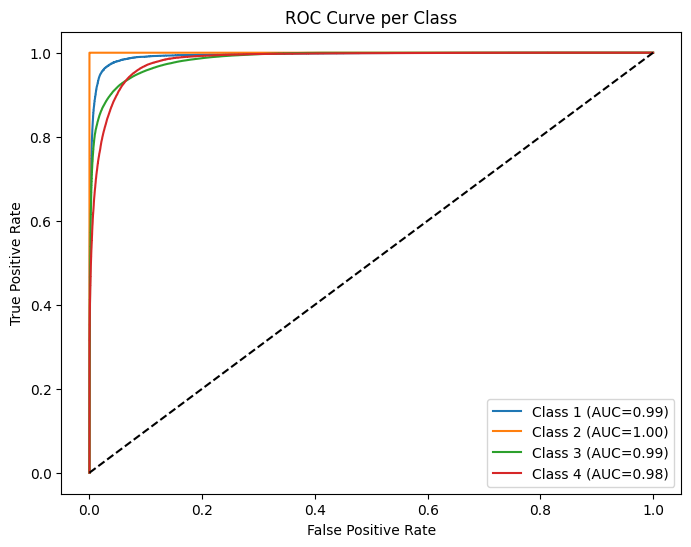

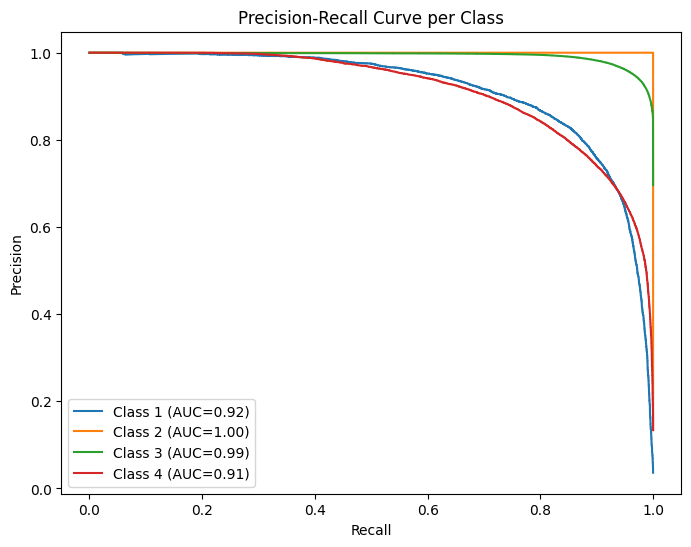

In [61]:
# ==============================
# 14. Classification report
# ==============================
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_custom))

# ==============================
# 15. Confusion matrix plot
# ==============================
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ==============================
# 16. ROC curve per class
# ==============================
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve((y_test==cls).astype(int), y_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# ==============================
# 17. Precision-Recall curve per class
# ==============================
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve((y_test==cls).astype(int), y_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {cls} (AUC={pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()

In [17]:
#  Keep original categorical values
train_cat_original = train[CAT_COLS].copy()

In [32]:
# Temporary Ordinal Encoding for Downsampling
temp_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_temp = train.drop(TARGET_COL, axis=1).copy()
X_temp[CAT_COLS] = temp_encoder.fit_transform(X_temp[CAT_COLS])
train_encoded = pd.concat([X_temp, train[TARGET_COL]], axis=1)



In [33]:
# Behavior-Preserving Similarity-Based Downsampling
def behavior_preserving_downsample_deterministic(df_encode, target_col=TARGET_COL, n_clusters=100, target_counts=None):
    """
    Downsample large classes deterministically while preserving rare classes.
    - target_counts: {class_label: exact_number_of_rows_after_downsampling}
    """
    df_list = []
    classes = df_encode[target_col].unique()
    
    for cls in classes:
        df_cls = df_encode[df_encode[target_col]==cls].copy()
        X_cls = df_cls.drop(columns=[target_col])
        
        # If class is rare or target count >= current, keep all
        target_n = target_counts.get(cls, len(df_cls)) if target_counts else len(df_cls)
        if target_n >= len(df_cls):
            df_list.append(df_cls)
            continue
        
        # Clustering
        n_clusters_cls = min(n_clusters, len(df_cls))
        kmeans = MiniBatchKMeans(n_clusters=n_clusters_cls, random_state=RANDOM_STATE, batch_size=10000)
        df_cls['cluster'] = kmeans.fit_predict(X_cls)
        
        # Calculate proportion per cluster
        cluster_sizes = df_cls['cluster'].value_counts().to_dict()
        sampled_list = []
        for cluster_id, size in cluster_sizes.items():
            # Number of rows to sample in this cluster proportional to cluster size
            n_samples = max(1, int(size / len(df_cls) * target_n))
            sampled = df_cls[df_cls['cluster']==cluster_id].sample(n=n_samples, random_state=RANDOM_STATE)
            sampled_list.append(sampled)
        
        sampled_cls = pd.concat(sampled_list)
        
        # If rounding caused fewer/more rows, adjust exactly
        if len(sampled_cls) < target_n:
            diff = target_n - len(sampled_cls)
            extra = df_cls.drop(sampled_cls.index).sample(n=diff, random_state=RANDOM_STATE)
            sampled_cls = pd.concat([sampled_cls, extra])
        elif len(sampled_cls) > target_n:
            sampled_cls = sampled_cls.sample(n=target_n, random_state=RANDOM_STATE)
        
        df_list.append(sampled_cls.drop(columns='cluster'))
    
    return pd.concat(df_list).sample(frac=1, random_state=RANDOM_STATE)

In [34]:
# Fractions for downsampling majority classes
target_counts = {
    1: 39556,   # keep all minor class
    2: 360336,  # downsample but preserve variability
    3: 114768,  # downsample moderately
    4: 106064   # keep all critical class
}

train_balanced = behavior_preserving_downsample_deterministic(train_encoded, n_clusters=200, target_counts=target_counts)
X_train_bal = train_balanced.drop(TARGET_COL, axis=1)
y_train_bal = train_balanced[TARGET_COL]

print("Class distribution after similarity-based downsampling:")
print(y_train_bal.value_counts())

Class distribution after similarity-based downsampling:
Severity
2    360336
3    114768
4    106064
1     39556
Name: count, dtype: int64


In [35]:
# Restore original categorical values
X_train_bal[CAT_COLS] = train_cat_original.loc[X_train_bal.index, CAT_COLS]

In [36]:
X_train_bal.head(5)

,Start_Lat,Start_Lng,Distance(mi),City,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,...,Hour_End_sin,Hour_End_cos,Minutes_Start_sin,Minutes_Start_cos,Minutes_End_sin,Minutes_End_cos,Day_sin,Day_cos,Month_sin,Month_cos
2276704,37.323059,-121.897224,0.000,San Jose,60.1,57.222527,90.0,29.41,10.0,South,...,1.000000,6.123234e-17,0.000000,1.000000,0.104528,-9.945219e-01,0.433884,-0.900969,0.866025,0.500000
1971533,33.575260,-111.874016,0.000,Scottsdale,64.0,64.000000,67.0,29.86,10.0,CALM,...,0.866025,-5.000000e-01,-0.104528,0.994522,-1.000000,-1.836970e-16,0.000000,1.000000,-0.500000,-0.866025
6869739,33.461405,-117.258843,0.647,Temecula,55.0,55.000000,44.0,28.59,10.0,NNE,...,0.866025,5.000000e-01,0.809017,0.587785,0.994522,1.045285e-01,-0.781831,0.623490,-0.500000,0.866025
9348,37.832893,-122.293678,0.010,Emeryville,50.0,44.644144,96.0,30.07,5.0,SE,...,1.000000,6.123234e-17,0.587785,-0.809017,0.000000,1.000000e+00,0.781831,0.623490,0.500000,0.866025
2004754,33.627239,-111.895599,0.000,Scottsdale,104.0,104.000000,18.0,28.18,10.0,CALM,...,-0.707107,-7.071068e-01,-0.866025,-0.500000,0.809017,5.877853e-01,0.433884,-0.900969,-0.866025,-0.500000


In [37]:
# Target Encoding (after downsampling)
encoder = TargetEncoder(cols=CAT_COLS, smoothing=10)
X_train_bal[CAT_COLS] = encoder.fit_transform(X_train_bal[CAT_COLS], y_train_bal)
X_test[CAT_COLS] = encoder.transform(X_test[CAT_COLS])


In [38]:
X_train_bal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 620724 entries, 2276704 to 131729
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Start_Lat              620724 non-null  float64
 1   Start_Lng              620724 non-null  float64
 2   Distance(mi)           620724 non-null  float64
 3   City                   620724 non-null  float64
 4   Temperature(F)         620724 non-null  float64
 5   Wind_Chill(F)          620724 non-null  float64
 6   Humidity(%)            620724 non-null  float64
 7   Pressure(in)           620724 non-null  float64
 8   Visibility(mi)         620724 non-null  float64
 9   Wind_Direction         620724 non-null  float64
 10  Wind_Speed(mph)        620724 non-null  float64
 11  Precipitation(in)      620724 non-null  float64
 12  Weather_Condition      620724 non-null  float64
 13  Amenity                620724 non-null  int64  
 14  Bump                   620724 non-n

In [39]:
# 10. Scaling
# ============================================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_bal), columns=X_train_bal.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [40]:
X_train_scaled.head(5)

,Start_Lat,Start_Lng,Distance(mi),City,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,...,Hour_End_sin,Hour_End_cos,Minutes_Start_sin,Minutes_Start_cos,Minutes_End_sin,Minutes_End_cos,Day_sin,Day_cos,Month_sin,Month_cos
0,0.198830,-1.733911,-0.459537,-0.656487,-0.108313,-0.166637,1.087846,-0.353706,0.380215,2.077631,...,1.499903,0.308181,0.012452,1.418222,0.144301,-1.402923,0.429019,-1.143717,1.302196,0.643306
1,-0.555604,-1.135217,-0.459537,-0.984816,0.098790,0.154234,0.068659,0.414160,0.380215,-0.165031,...,1.319655,-0.485693,-0.135120,1.410461,-1.421166,0.000488,-0.228844,1.446964,-0.688783,-1.237643
2,-0.578523,-1.456857,0.044132,0.028003,-0.379140,-0.271859,-0.950528,-1.752930,0.380215,-0.235850,...,1.319655,1.102056,1.154611,0.834211,1.405704,0.147992,-1.414272,0.933848,-0.688783,1.147305
3,0.301459,-1.757591,-0.451753,0.316938,-0.644656,-0.762144,1.353720,0.772498,-1.744384,-0.325702,...,1.499903,0.308181,0.842279,-1.144730,-0.003849,1.411628,0.956584,0.933848,0.768715,1.147305
4,-0.545140,-1.136507,-0.459537,-0.984816,2.222920,2.047982,-2.102653,-2.452541,0.380215,-0.165031,...,-0.796828,-0.814527,-1.210192,-0.706925,1.142785,0.829935,0.429019,-1.143717,-1.222264,-0.733644


In [41]:
#Class Weights & Mapping
class_weights_dict = {0: 20, 1: 1, 2: 3, 3: 20}  # Custom weights
sample_weights = np.array([class_weights_dict[y] for y in y_train_mapped])

# Custom scorer for Class 4 recall
recall_class4_scorer = make_scorer(recall_score, labels=[3], average='macro')

In [42]:
# 9. Train XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=4,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

xgb.fit(X_train_scaled, y_train_mapped, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=4, ...)


Classification Report:
              precision    recall  f1-score   support

           0      0.219     0.961     0.357      9889
           1      0.974     0.501     0.662   1126347
           2      0.540     0.810     0.648    239280
           3      0.061     0.965     0.114     26516

    accuracy                          0.566   1402032
   macro avg      0.448     0.809     0.445   1402032
weighted avg      0.878     0.566     0.647   1402032

Weighted F1 Score: 0.6467722912112857
Weighted F2 Score: 0.5799902097223142


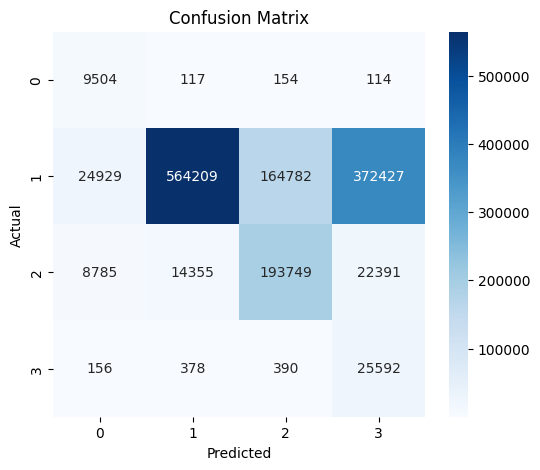

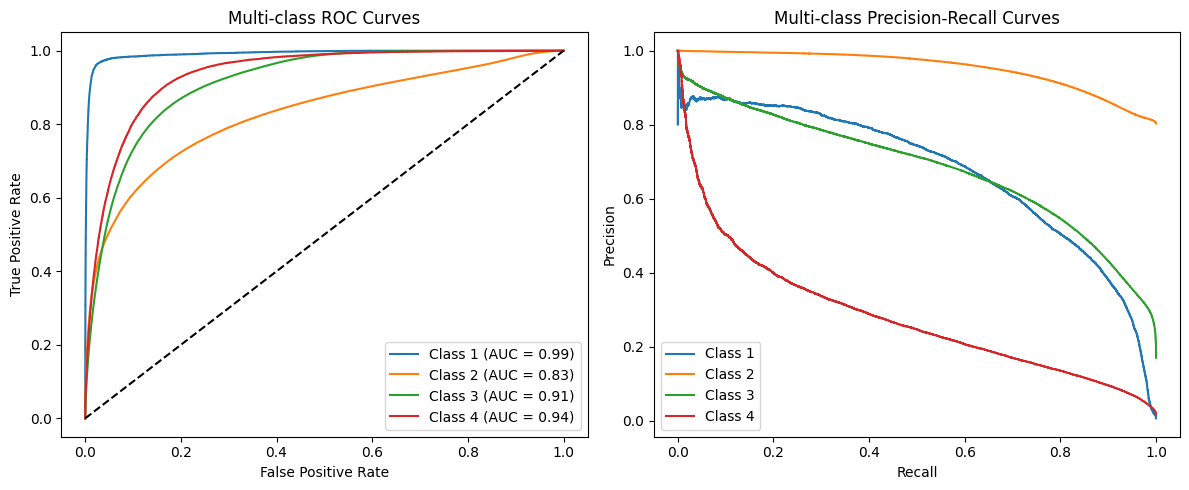

In [43]:
# Evaluation
# ============================================
y_pred = xgb.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test_mapped, y_pred, digits=3))
print("Weighted F1 Score:", fbeta_score(y_test_mapped, y_pred, beta=1, average='weighted'))
print("Weighted F2 Score:", fbeta_score(y_test_mapped, y_pred, beta=2, average='weighted'))

cm = confusion_matrix(y_test_mapped, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================
# 11. ROC & Precision-Recall Curves
# ============================================
y_test_bin = label_binarize(y_test_mapped, classes=[0,1,2,3])
y_pred_prob = xgb.predict_proba(X_test_scaled)

plt.figure(figsize=(12,5))

# ROC Curves
plt.subplot(1,2,1)
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title('Multi-class ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

# Precision-Recall Curves
plt.subplot(1,2,2)
for i in range(y_test_bin.shape[1]):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title('Multi-class Precision-Recall Curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0      0.042     0.976     0.081      9889
           1      0.980     0.369     0.536   1126347
           2      0.578     0.709     0.637    239280
           3      0.056     0.969     0.106     26516

    accuracy                          0.443   1402032
   macro avg      0.414     0.756     0.340   1402032
weighted avg      0.887     0.443     0.542   1402032



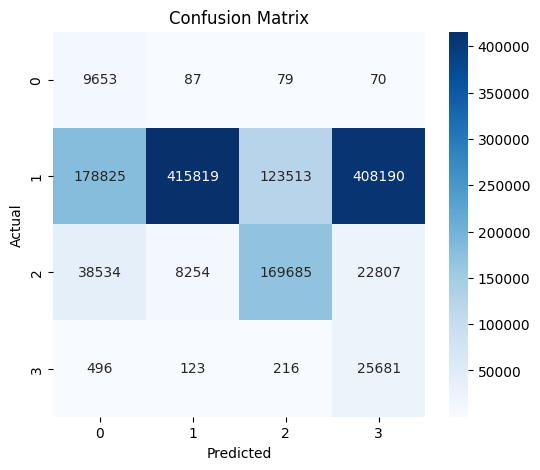

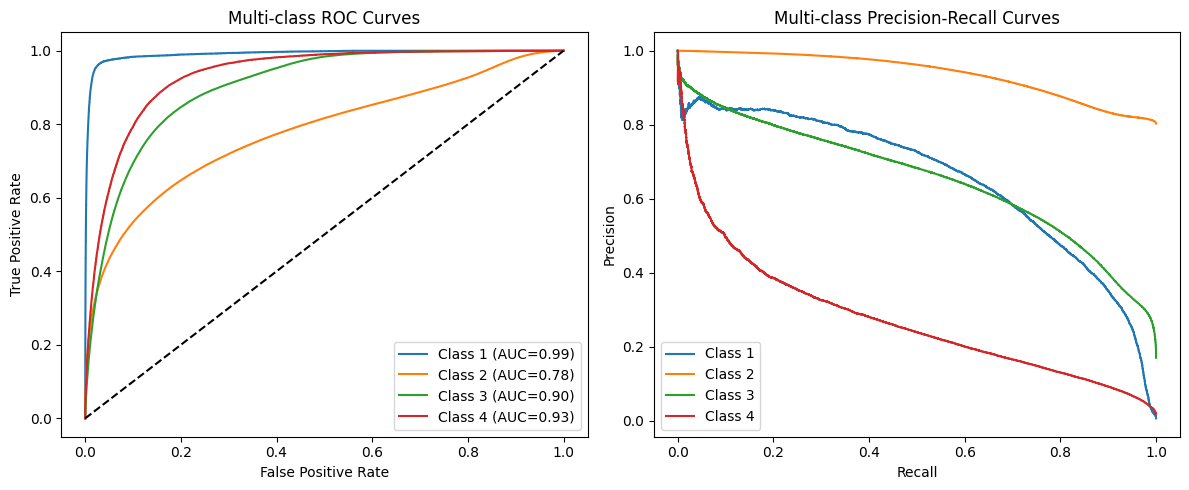

In [46]:
# Class Weights
y_train_mapped = y_train_bal - 1
y_test_mapped = y_test - 1

class_weights_dict = {0:50, 1:1, 2:3, 3:50}  # Increase weight for Classes 1 & 4
sample_weights = np.array([class_weights_dict[y] for y in y_train_mapped])

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=4,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
xgb.fit(X_train_scaled, y_train_mapped, sample_weight=sample_weights)

# Threshold Tuning for Class 1 & 4
y_prob = xgb.predict_proba(X_test_scaled)
thresholds = {0:0.6, 1:0.5, 2:0.5, 3:0.6}  # adjust thresholds for rare classes

y_pred_adjusted = np.zeros(y_prob.shape[0], dtype=int)
for i in range(y_prob.shape[0]):
    probs = y_prob[i]
    adjusted_probs = probs.copy()
    for cls in range(4):
        if probs[cls] < thresholds[cls]:
            adjusted_probs[cls] = 0
    y_pred_adjusted[i] = np.argmax(adjusted_probs)

#  Evaluation
print("\nClassification Report:")
print(classification_report(y_test_mapped, y_pred_adjusted, digits=3))
cm = confusion_matrix(y_test_mapped, y_pred_adjusted)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC & Precision-Recall Curves
y_test_bin = label_binarize(y_test_mapped, classes=[0,1,2,3])

plt.figure(figsize=(12,5))

# ROC Curves
plt.subplot(1,2,1)
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("Multi-class ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')

# Precision-Recall Curves
plt.subplot(1,2,2)
for i in range(y_test_bin.shape[1]):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title("Multi-class Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0      0.021     0.982     0.040      9889
           1      0.980     0.369     0.536   1126347
           2      0.578     0.709     0.637    239280
           3      0.108     0.864     0.191     26516

    accuracy                          0.441   1402032
   macro avg      0.422     0.731     0.351   1402032
weighted avg      0.888     0.441     0.543   1402032



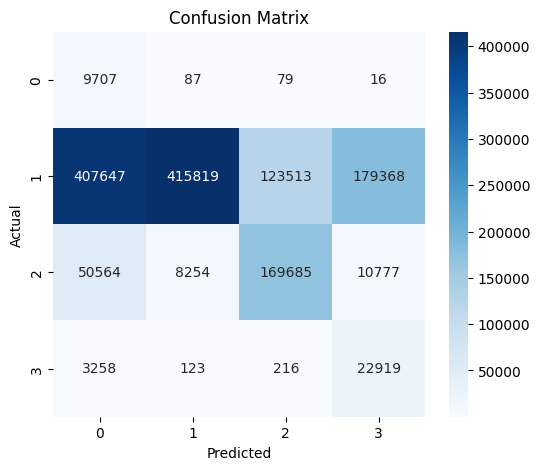

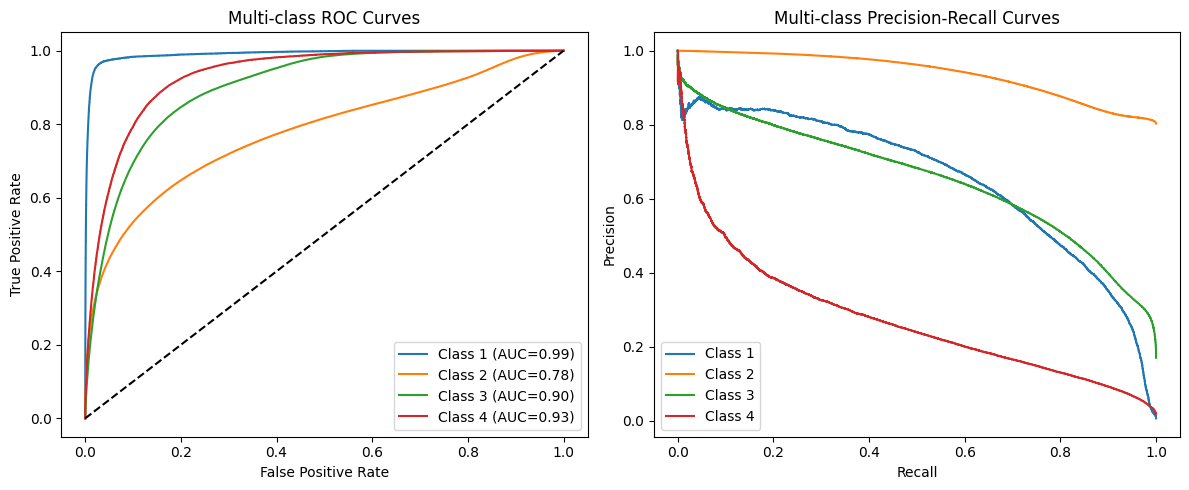

In [47]:
#  Class Weights
y_train_mapped = y_train_bal - 1
y_test_mapped = y_test - 1

class_weights_dict = {0:50, 1:1, 2:3, 3:50}  # Increase weight for Classes 1 & 4
sample_weights = np.array([class_weights_dict[y] for y in y_train_mapped])

#  Train XGBoost

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=4,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
xgb.fit(X_train_scaled, y_train_mapped, sample_weight=sample_weights)


# Automated Threshold Optimization (F2) for Classes 1 & 4

y_prob = xgb.predict_proba(X_test_scaled)
thresholds = {0:0.5, 1:0.5, 2:0.5, 3:0.5}

def optimize_threshold(y_true, y_prob_class, beta=2):
    best_fbeta = 0
    best_thresh = 0.5
    for t in np.arange(0.1, 0.91, 0.01):
        y_pred = (y_prob_class >= t).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, average='binary')
        if score > best_fbeta:
            best_fbeta = score
            best_thresh = t
    return best_thresh

# Optimize only for Class 1 (0) and Class 4 (3)
for cls in [0,3]:
    thresholds[cls] = optimize_threshold((y_test_mapped==cls).astype(int), y_prob[:,cls], beta=2)

# Apply thresholds
y_pred_adjusted = np.zeros(y_prob.shape[0], dtype=int)
for i in range(y_prob.shape[0]):
    probs = y_prob[i]
    adjusted_probs = probs.copy()
    for cls in range(4):
        if probs[cls] < thresholds[cls]:
            adjusted_probs[cls] = 0
    y_pred_adjusted[i] = np.argmax(adjusted_probs)

#  Evaluation

print("\nClassification Report:")
print(classification_report(y_test_mapped, y_pred_adjusted, digits=3))

cm = confusion_matrix(y_test_mapped, y_pred_adjusted)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC & Precision-Recall Curves

y_test_bin = label_binarize(y_test_mapped, classes=[0,1,2,3])

plt.figure(figsize=(12,5))
# ROC Curves
plt.subplot(1,2,1)
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("Multi-class ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')

# Precision-Recall Curves
plt.subplot(1,2,2)
for i in range(y_test_bin.shape[1]):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title("Multi-class Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

     Class 1      0.170     0.950     0.288      9889
     Class 2      0.979     0.686     0.807   1126347
     Class 3      0.477     0.866     0.615    239280
     Class 4      0.159     0.735     0.261     26516

    accuracy                          0.720   1402032
   macro avg      0.446     0.809     0.493   1402032
weighted avg      0.872     0.720     0.760   1402032



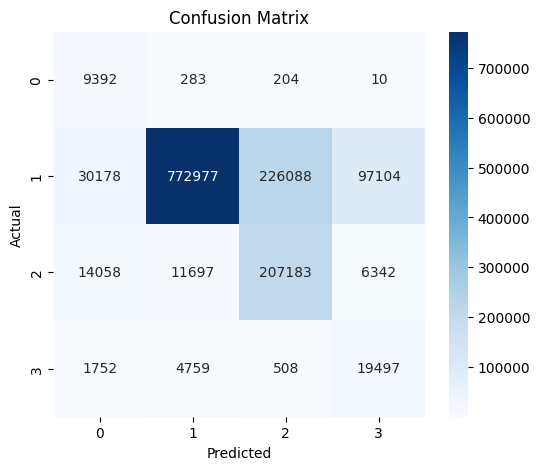

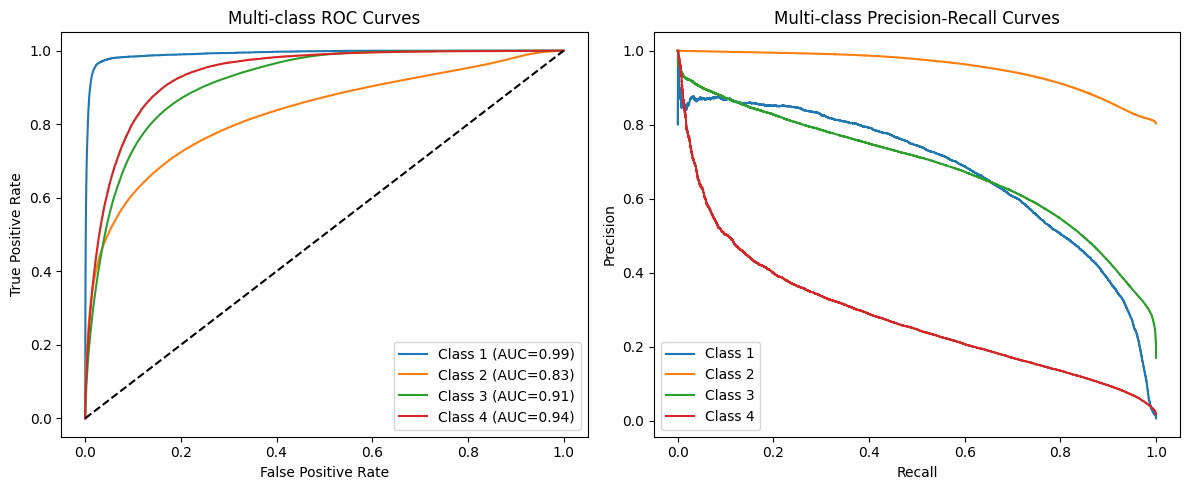

In [49]:

#  Single Multiclass XGBoost with class weights

# Map classes to 0-based index
class_mapping = {1:0, 2:1, 3:2, 4:3}
y_train_idx = y_train_bal.map(class_mapping).values
y_test_idx = y_test.map(class_mapping).values

# Class weights to boost rare classes
class_weights = {0:20, 1:1, 2:3, 3:20}
sample_weights = np.array([class_weights[i] for i in y_train_idx])

xgb = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='multi:softprob', eval_metric='mlogloss',
    random_state=RANDOM_STATE
)
xgb.fit(X_train_scaled, y_train_idx, sample_weight=sample_weights)


#  Predict and Threshold Optimization
y_prob = xgb.predict_proba(X_test_scaled)

# Optimize thresholds for precision/recall per class
def optimize_thresholds(y_true, y_prob, beta=2):
    thresholds = np.ones(y_prob.shape[1])*0.5
    for i in range(y_prob.shape[1]):
        best_fbeta = 0
        best_thresh = 0.5
        for t in np.arange(0.1,0.91,0.01):
            y_pred_i = (y_prob[:,i]>=t).astype(int)
            score = fbeta_score((y_true==i).astype(int), y_pred_i, beta=beta)
            if score > best_fbeta:
                best_fbeta = score
                best_thresh = t
        thresholds[i] = best_thresh
    return thresholds

thresholds = optimize_thresholds(y_test_idx, y_prob, beta=2)

y_pred_final = np.zeros(y_test_idx.shape, dtype=int)
for i in range(y_prob.shape[1]):
    idx = y_prob[:,i] >= thresholds[i]
    y_pred_final[idx] = i

# Evaluation
print("Classification Report:")
print(classification_report(y_test_idx, y_pred_final, target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

cm = confusion_matrix(y_test_idx, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC & Precision-Recall Curves
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test_idx, classes=[0,1,2,3])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("Multi-class ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')

plt.subplot(1,2,2)
for i in range(4):
    precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob[:,i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title("Multi-class Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

     Class 1      0.170     0.950     0.288      9889
     Class 2      0.979     0.686     0.807   1126347
     Class 3      0.477     0.866     0.615    239280
     Class 4      0.159     0.735     0.261     26516

    accuracy                          0.720   1402032
   macro avg      0.446     0.809     0.493   1402032
weighted avg      0.872     0.720     0.760   1402032



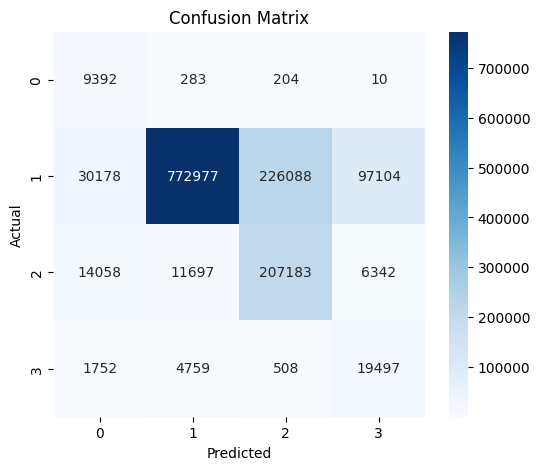

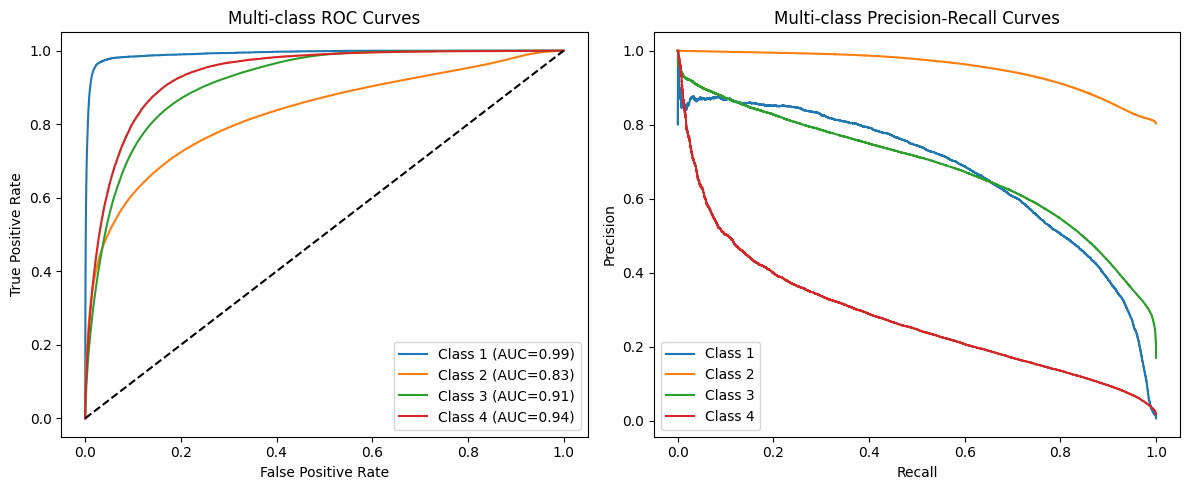

In [50]:
# Map Classes to 0-based Index

class_mapping = {1:0, 2:1, 3:2, 4:3}
y_train_idx = y_train_bal.map(class_mapping).values
y_test_idx = y_test.map(class_mapping).values


# Train XGBoost with Class Weights
class_weights = {0:20, 1:1, 2:3, 3:20}
sample_weights = np.array([class_weights[i] for i in y_train_idx])

xgb = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='multi:softprob', eval_metric='mlogloss',
    random_state=RANDOM_STATE
)
xgb.fit(X_train_scaled, y_train_idx, sample_weight=sample_weights)

#  Predict and Optimize Thresholds per Class
y_prob = xgb.predict_proba(X_test_scaled)

def optimize_thresholds(y_true, y_prob, beta=2):
    thresholds = np.ones(y_prob.shape[1])*0.5
    for i in range(y_prob.shape[1]):
        best_fbeta = 0
        best_thresh = 0.5
        for t in np.arange(0.1,0.91,0.01):
            y_pred_i = (y_prob[:,i]>=t).astype(int)
            score = fbeta_score((y_true==i).astype(int), y_pred_i, beta=beta)
            if score > best_fbeta:
                best_fbeta = score
                best_thresh = t
        thresholds[i] = best_thresh
    return thresholds

thresholds = optimize_thresholds(y_test_idx, y_prob, beta=2)

y_pred_final = np.zeros(y_test_idx.shape, dtype=int)
for i in range(y_prob.shape[1]):
    idx = y_prob[:,i] >= thresholds[i]
    y_pred_final[idx] = i

# Evaluation
print("Classification Report:")
print(classification_report(y_test_idx, y_pred_final, target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

cm = confusion_matrix(y_test_idx, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC & Precision-Recall Curves
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test_idx, classes=[0,1,2,3])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("Multi-class ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')

plt.subplot(1,2,2)
for i in range(4):
    precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob[:,i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title("Multi-class Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

     Class 1      0.450     0.852     0.589      9889
     Class 2      0.975     0.696     0.812   1126347
     Class 3      0.540     0.863     0.665    239280
     Class 4      0.114     0.847     0.201     26516

    accuracy                          0.728   1402032
   macro avg      0.520     0.815     0.566   1402032
weighted avg      0.881     0.728     0.774   1402032



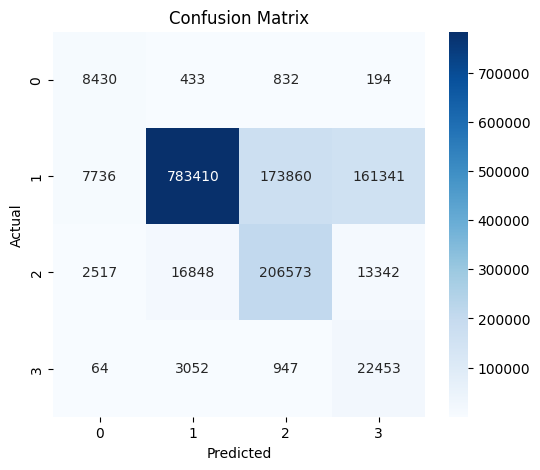

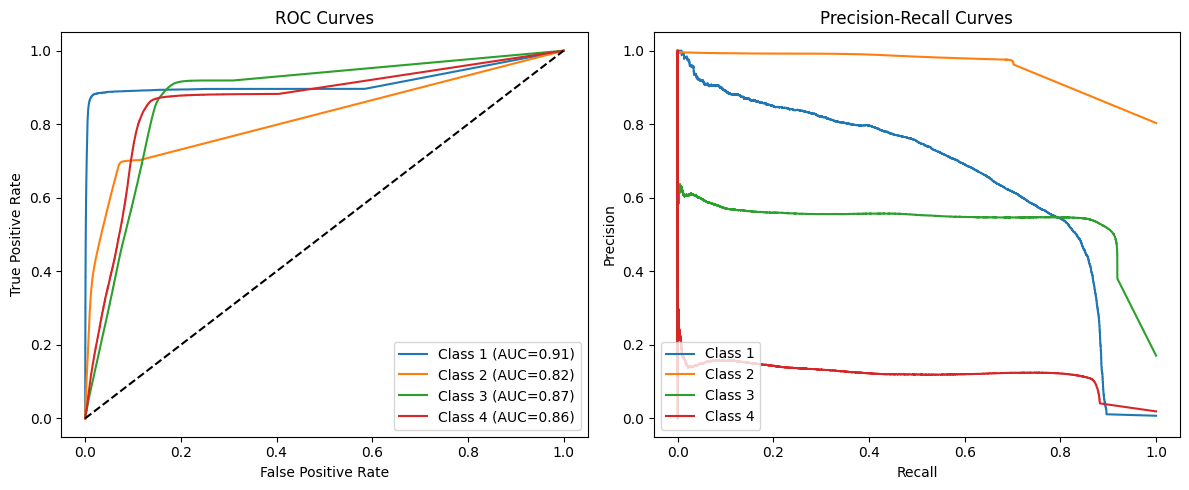

In [54]:


# Map Classes to 0-based Index
class_mapping = {1:0, 2:1, 3:2, 4:3}
y_train_idx = y_train_bal.map(class_mapping).values
y_test_idx = y_test.map(class_mapping).values

#  Compute Class Weights
classes = np.unique(y_train_idx)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_idx)
class_weights = {i:w for i,w in zip(classes, weights)}
sample_weights = np.array([class_weights[i] for i in y_train_idx])

#  Stage-wise XGBoost
# Stage 1: Minor (1&2) vs Critical (3&4)
y_train_stage1 = np.where(y_train_idx<=1, 0, 1)
y_test_stage1 = np.where(y_test_idx<=1, 0, 1)
sample_weights_stage1 = np.where(y_train_stage1==1, 3, 1)

xgb_stage1 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='binary:logistic', eval_metric='logloss',
    random_state=RANDOM_STATE
)
xgb_stage1.fit(X_train_scaled, y_train_stage1, sample_weight=sample_weights_stage1)
y_prob_stage1 = xgb_stage1.predict_proba(X_test_scaled)[:,1]
threshold_stage1 = 0.5
y_pred_stage1 = (y_prob_stage1>=threshold_stage1).astype(int)

# Stage 2: Sub-classification
minor_idx_train = np.where(y_train_stage1==0)[0]
critical_idx_train = np.where(y_train_stage1==1)[0]
minor_idx_test = np.where(y_pred_stage1==0)[0]
critical_idx_test = np.where(y_pred_stage1==1)[0]

# Minor classifier (1 vs 2)
y_train_minor = y_train_idx[minor_idx_train]
X_train_minor = X_train_scaled.iloc[minor_idx_train]
xgb_minor = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_minor.fit(X_train_minor, (y_train_minor==1).astype(int))
y_prob_minor = xgb_minor.predict_proba(X_test_scaled.iloc[minor_idx_test])[:,1]

# Critical classifier (3 vs 4)
y_train_critical = y_train_idx[critical_idx_train]
X_train_critical = X_train_scaled.iloc[critical_idx_train]
xgb_critical = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_critical.fit(X_train_critical, (y_train_critical==3).astype(int))
y_prob_critical = xgb_critical.predict_proba(X_test_scaled.iloc[critical_idx_test])[:,1]

#  Combine Stage Predictions
y_pred_final = np.zeros_like(y_test_idx)
y_pred_final[minor_idx_test] = np.where(y_prob_minor>=0.5,1,0)
y_pred_final[critical_idx_test] = np.where(y_prob_critical>=0.5,3,2)

#  Evaluation
print("Classification Report:")
print(classification_report(y_test_idx, y_pred_final, target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

cm = confusion_matrix(y_test_idx, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC & Precision-Recall Curves
y_test_bin = label_binarize(y_test_idx, classes=[0,1,2,3])
y_prob_full = np.zeros_like(y_test_bin, dtype=float)
y_prob_full[minor_idx_test,0] = 1 - y_prob_minor
y_prob_full[minor_idx_test,1] = y_prob_minor
y_prob_full[critical_idx_test,2] = 1 - y_prob_critical
y_prob_full[critical_idx_test,3] = y_prob_critical

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_full[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')

plt.subplot(1,2,2)
for i in range(4):
    precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob_full[:,i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

     Class 1      0.450     0.852     0.589      9889
     Class 2      0.975     0.696     0.812   1126347
     Class 3      0.540     0.862     0.664    239280
     Class 4      0.113     0.846     0.200     26516

    accuracy                          0.728   1402032
   macro avg      0.520     0.814     0.566   1402032
weighted avg      0.881     0.728     0.773   1402032



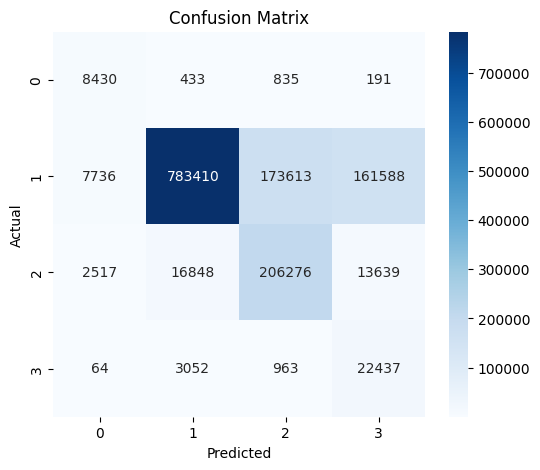

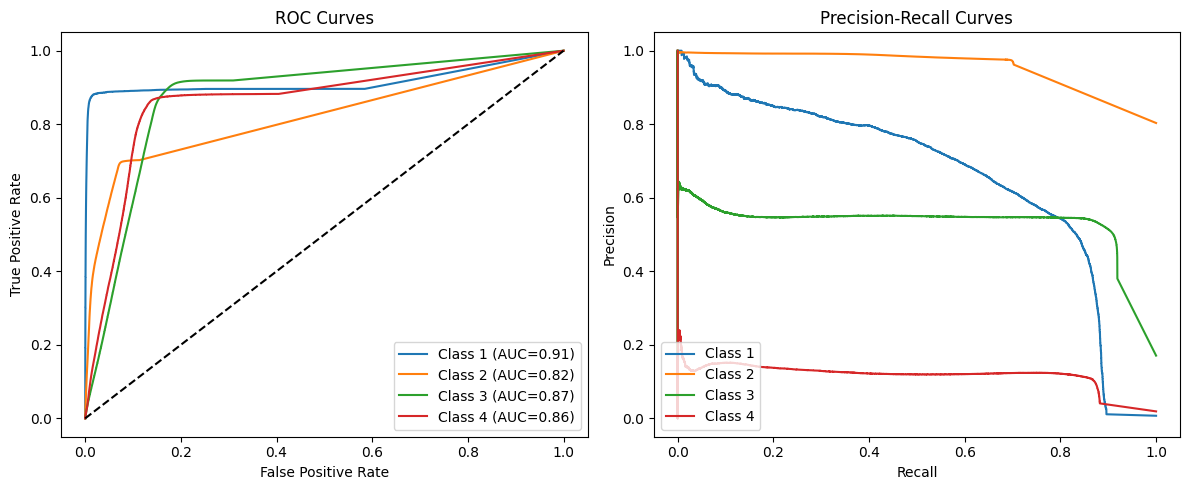

In [55]:
# Map Classes to 0-based Index
class_mapping = {1:0, 2:1, 3:2, 4:3}
y_train_idx = y_train_bal.map(class_mapping).values
y_test_idx = y_test.map(class_mapping).values

#  Compute Class Weights

classes = np.unique(y_train_idx)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_idx)
class_weights = {i:w for i,w in zip(classes, weights)}
sample_weights = np.array([class_weights[i] for i in y_train_idx])


#  Stage-wise XGBoost
# Stage 1: Minor (1&2) vs Critical (3&4)
y_train_stage1 = np.where(y_train_idx<=1, 0, 1)
y_test_stage1 = np.where(y_test_idx<=1, 0, 1)
sample_weights_stage1 = np.where(y_train_stage1==1, 3, 1)

xgb_stage1 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='binary:logistic', eval_metric='logloss',
    random_state=RANDOM_STATE
)
xgb_stage1.fit(X_train_scaled, y_train_stage1, sample_weight=sample_weights_stage1)
y_prob_stage1 = xgb_stage1.predict_proba(X_test_scaled)[:,1]
threshold_stage1 = 0.5
y_pred_stage1 = (y_prob_stage1>=threshold_stage1).astype(int)

# Stage 2: Sub-classification
minor_idx_train = np.where(y_train_stage1==0)[0]
critical_idx_train = np.where(y_train_stage1==1)[0]
minor_idx_test = np.where(y_pred_stage1==0)[0]
critical_idx_test = np.where(y_pred_stage1==1)[0]

# Minor classifier (Class 1 vs Class 2)
y_train_minor = y_train_idx[minor_idx_train]
X_train_minor = X_train_scaled.iloc[minor_idx_train]
xgb_minor = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_minor.fit(X_train_minor, (y_train_minor==1).astype(int))
y_prob_minor = xgb_minor.predict_proba(X_test_scaled.iloc[minor_idx_test])[:,1]
y_pred_minor_final = (y_prob_minor>=0.5).astype(int)

# Critical classifier (Class 3 vs Class 4) with Class 4 weighting
y_train_critical = y_train_idx[critical_idx_train]
X_train_critical = X_train_scaled.iloc[critical_idx_train]
sample_weights_critical = np.where(y_train_critical==3, 10, 1)
xgb_critical = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_critical.fit(X_train_critical, (y_train_critical==3).astype(int), sample_weight=sample_weights_critical)
y_prob_critical = xgb_critical.predict_proba(X_test_scaled.iloc[critical_idx_test])[:,1]

# Optimize Class 4 threshold
def optimize_class_threshold(y_true, y_prob, beta=1):
    best_thresh = 0.5
    best_score = 0
    for t in np.arange(0.1, 0.91, 0.01):
        y_pred = (y_prob >= t).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, average='binary')
        if score > best_score:
            best_score = score
            best_thresh = t
    return best_thresh

y_test_critical_orig = (y_test_idx[critical_idx_test]==3).astype(int)
threshold_class4 = optimize_class_threshold(y_test_critical_orig, y_prob_critical, beta=1)
y_pred_critical_final = (y_prob_critical>=threshold_class4).astype(int)

# Combine Stage Predictions
y_pred_final = np.zeros_like(y_test_idx)
y_pred_final[minor_idx_test] = np.where(y_pred_minor_final==1,1,0)
y_pred_final[critical_idx_test] = np.where(y_pred_critical_final==1,3,2)

#  Evaluation
print("Classification Report:")
print(classification_report(y_test_idx, y_pred_final,
                            target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

cm = confusion_matrix(y_test_idx, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC & Precision-Recall Curves
y_test_bin = label_binarize(y_test_idx, classes=[0,1,2,3])
y_prob_full = np.zeros_like(y_test_bin, dtype=float)
y_prob_full[minor_idx_test,0] = 1 - y_prob_minor
y_prob_full[minor_idx_test,1] = y_prob_minor
y_prob_full[critical_idx_test,2] = 1 - y_prob_critical
y_prob_full[critical_idx_test,3] = y_prob_critical

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_full[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')

plt.subplot(1,2,2)
for i in range(4):
    precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob_full[:,i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

     Class 1      0.452     0.851     0.591      9889
     Class 2      0.819     0.993     0.897   1126347
     Class 3      0.921     0.042     0.080    239280
     Class 4      0.497     0.129     0.205     26516

    accuracy                          0.813   1402032
   macro avg      0.672     0.504     0.443   1402032
weighted avg      0.828     0.813     0.743   1402032



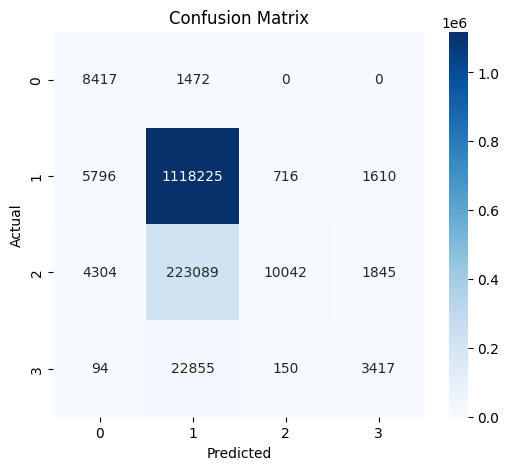

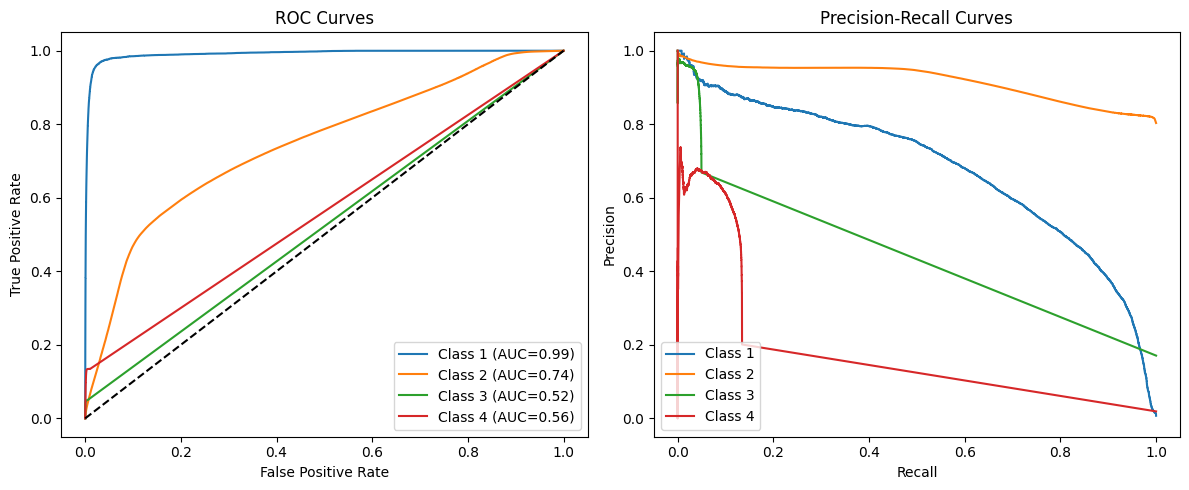

In [57]:
# Map Classes to 0-based Index
class_mapping = {1:0, 2:1, 3:2, 4:3}
y_train_idx = y_train_bal.map(class_mapping).values
y_test_idx = y_test.map(class_mapping).values

#  Class Weights
class_weights = {0:20, 1:1, 2:3, 3:20}
sample_weights = np.array([class_weights[i] for i in y_train_idx])

#  Stage-wise XGBoost
# Stage 1: Minor (1&2) vs Critical (3&4)
y_train_stage1 = np.where(y_train_idx<=1, 0, 1)
y_test_stage1 = np.where(y_test_idx<=1, 0, 1)
sample_weights_stage1 = np.where(y_train_stage1==0, class_weights[0], class_weights[1])
xgb_stage1 = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    objective='binary:logistic', eval_metric='logloss',
    random_state=RANDOM_STATE
)
xgb_stage1.fit(X_train_scaled, y_train_stage1, sample_weight=sample_weights_stage1)
y_prob_stage1 = xgb_stage1.predict_proba(X_test_scaled)[:,1]
y_pred_stage1 = (y_prob_stage1>=0.5).astype(int)

# Stage 2: Minor classifier (Class 1 vs Class 2)
minor_idx_test = np.where(y_pred_stage1==0)[0]
minor_idx_train = np.where(y_train_stage1==0)[0]
X_train_minor = X_train_scaled.iloc[minor_idx_train]
y_train_minor = y_train_idx[minor_idx_train]
xgb_minor = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
                          tree_method='hist',objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE)
xgb_minor.fit(X_train_minor, (y_train_minor==1).astype(int))
y_prob_minor = xgb_minor.predict_proba(X_test_scaled.iloc[minor_idx_test])[:,1]

# Optimize threshold for Class 1 to improve precision
def optimize_threshold(y_true, y_prob, beta=1):
    best_thresh = 0.5
    best_score = 0
    for t in np.arange(0.1,0.91,0.01):
        y_pred = (y_prob>=t).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, average='binary')
        if score>best_score:
            best_score = score
            best_thresh = t
    return best_thresh

y_test_minor_orig = (y_test_idx[minor_idx_test]==1).astype(int)
threshold_class1 = optimize_threshold(y_test_minor_orig, y_prob_minor, beta=1)
y_pred_minor_final = (y_prob_minor>=threshold_class1).astype(int)

# Stage 2: Critical classifier (Class 3 vs Class 4)
critical_idx_test = np.where(y_pred_stage1==1)[0]
critical_idx_train = np.where(y_train_stage1==1)[0]
X_train_critical = X_train_scaled.iloc[critical_idx_train]
y_train_critical = y_train_idx[critical_idx_train]
sample_weights_critical = np.where(y_train_critical==3, class_weights[3], class_weights[2])
xgb_critical = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
                             tree_method='hist',objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE)
xgb_critical.fit(X_train_critical, (y_train_critical==3).astype(int), sample_weight=sample_weights_critical)
y_prob_critical = xgb_critical.predict_proba(X_test_scaled.iloc[critical_idx_test])[:,1]
y_test_critical_orig = (y_test_idx[critical_idx_test]==3).astype(int)
threshold_class4 = optimize_threshold(y_test_critical_orig, y_prob_critical, beta=1)
y_pred_critical_final = (y_prob_critical>=threshold_class4).astype(int)

#  Combine Predictions
y_pred_final = np.zeros_like(y_test_idx)
y_pred_final[minor_idx_test] = np.where(y_pred_minor_final==1,1,0)
y_pred_final[critical_idx_test] = np.where(y_pred_critical_final==1,3,2)

#  Evaluation

print("Classification Report:")
print(classification_report(y_test_idx, y_pred_final,
                            target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

cm = confusion_matrix(y_test_idx, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC & Precision-Recall Curves
y_test_bin = label_binarize(y_test_idx, classes=[0,1,2,3])
y_prob_full = np.zeros_like(y_test_bin, dtype=float)
y_prob_full[minor_idx_test,0] = 1 - y_prob_minor
y_prob_full[minor_idx_test,1] = y_prob_minor
y_prob_full[critical_idx_test,2] = 1 - y_prob_critical
y_prob_full[critical_idx_test,3] = y_prob_critical

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_full[:,i])
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')

plt.subplot(1,2,2)
for i in range(4):
    precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob_full[:,i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

     Class 1      0.245     0.954     0.391      9889
     Class 2      0.933     0.840     0.884   1126347
     Class 3      0.627     0.698     0.661    239280
     Class 4      0.187     0.590     0.284     26516

    accuracy                          0.812   1402032
   macro avg      0.498     0.771     0.555   1402032
weighted avg      0.862     0.812     0.831   1402032



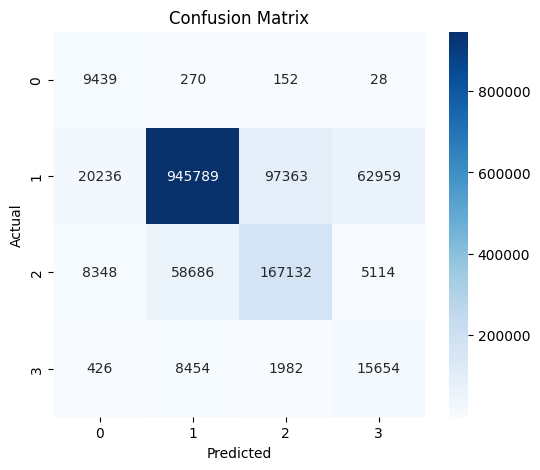

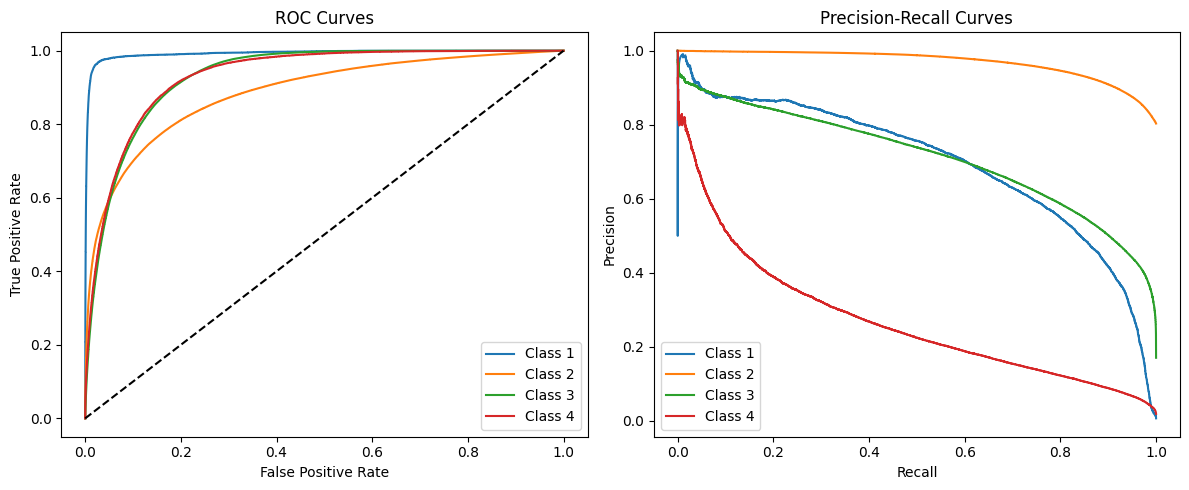

In [58]:

# Map Classes to 0-based Index
class_mapping = {1:0, 2:1, 3:2, 4:3}
y_train_idx = y_train_bal.map(class_mapping).values
y_test_idx = y_test.map(class_mapping).values

# Class weights to improve minority recall
class_weights = {0:5, 1:1, 2:15, 3:20}  # Aggressive for Class 3 and 4
sample_weights = np.array([class_weights[i] for i in y_train_idx])

# Train One-vs-Rest XGBoost for all classes
n_classes = 4
y_train_bin = label_binarize(y_train_idx, classes=range(n_classes))
y_test_bin = label_binarize(y_test_idx, classes=range(n_classes))

y_prob_all = np.zeros_like(y_test_bin, dtype=float)

for i in range(n_classes):
    xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, tree_method='hist',
        objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE
    )
    w = np.where(y_train_bin[:,i]==1, class_weights[i],1)
    xgb.fit(X_train_scaled, y_train_bin[:,i], sample_weight=w)
    y_prob_all[:,i] = xgb.predict_proba(X_test_scaled)[:,1]

# Optimize thresholds for Class 3 & Class 4 to increase recall
thresholds = [0.5]*4
for i in [2,3]:  # Class 3 & 4
    best_thresh = 0.5
    best_score = 0
    for t in np.arange(0.1,0.91,0.01):
        y_pred = (y_prob_all[:,i]>=t).astype(int)
        score = fbeta_score(y_test_bin[:,i], y_pred, beta=2)  # prioritize recall
        if score>best_score:
            best_score=score
            best_thresh=t
    thresholds[i] = best_thresh

y_pred_final = np.argmax(y_prob_all>=thresholds, axis=1)

# Evaluation
print("Classification Report:")
print(classification_report(y_test_idx, y_pred_final,
                            target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

cm = confusion_matrix(y_test_idx, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC & Precision-Recall curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_all[:,i])
    plt.plot(fpr,tpr,label=f'Class {i+1}')
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.subplot(1,2,2)
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob_all[:,i])
    plt.plot(recall, precision, label=f'Class {i+1}')
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Combine features and target for sampling
train_bal = pd.concat([X_train, y_train], axis=1)

# Apply proportional behavior-based sampling
for cls, max_count in MAX_SAMPLES.items():
    upsample = True if train_bal[TARGET_COL].value_counts()[cls] < max_count else False
    train_bal = behavior_sample(train_bal, target_class=cls, max_samples=max_count, upsample=upsample)

print("Class counts after proportional sampling:")
print(train_bal[TARGET_COL].value_counts())

Class counts after proportional sampling:
Severity
2    400000
3    200000
4    150000
1    100000
Name: count, dtype: int64


In [26]:
# Separate features and target
X_train_bal = train_bal.drop(TARGET_COL, axis=1)
y_train_bal = train_bal[TARGET_COL]

# Target encoding
cat_cols = X_train_bal.select_dtypes(include='object').columns.tolist()
num_cols = X_train_bal.select_dtypes(include=np.number).columns.tolist()

if len(cat_cols) > 0:
    te = TargetEncoder(cols=cat_cols)
    X_train_bal[cat_cols] = te.fit_transform(X_train_bal[cat_cols], y_train_bal)
    X_test[cat_cols] = te.transform(X_test[cat_cols])
# Scale numeric features
scaler = StandardScaler()
X_train_bal[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [27]:
# Shift labels for XGBoost
y_train_shift = (y_train_bal - 1).astype(int)
y_test_shift = (y_test - 1).astype(int)

#  Sample weights
weights = y_train_shift.map({0:5, 1:1, 2:2, 3:5}).to_numpy()

#  Train XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train_bal, y_train_shift, sample_weight=weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=4, ...)

In [29]:
#  Predict probabilities
y_test_proba = xgb.predict_proba(X_test)

#  Automatic threshold tuning per class
THRESHOLDS = {}
y_pred_auto = np.zeros_like(y_test_shift)

for cls in range(4):
    y_true_bin = (y_test_shift == cls).astype(int)
    best_f1 = 0
    best_thresh = 0.5
    for t in np.linspace(0.1, 0.9, 17):
        y_pred_bin = (y_test_proba[:,cls] >= t).astype(int)
        f1 = f1_score(y_true_bin, y_pred_bin)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    THRESHOLDS[cls] = best_thresh
    print(f"Class {cls+1} best threshold: {best_thresh:.2f}, F1: {best_f1:.2f}")

# Apply thresholds
for i in range(len(y_test_shift)):
    probs = y_test_proba[i]
    candidates = [j for j, p in enumerate(probs) if p >= THRESHOLDS[j]]
    y_pred_auto[i] = max(candidates) if candidates else np.argmax(probs)

Class 1 best threshold: 0.60, F1: 0.43
Class 2 best threshold: 0.10, F1: 0.87
Class 3 best threshold: 0.50, F1: 0.50
Class 4 best threshold: 0.70, F1: 0.19


In [30]:
# Initialize predictions
y_pred_final = np.zeros_like(y_test_shift)

for i in range(len(y_test_shift)):
    probs = y_test_proba[i]
    candidates = [j for j, p in enumerate(probs) if p >= THRESHOLDS[j]]
    # If no class meets threshold, fallback to class with highest probability
    y_pred_final[i] = max(candidates) if candidates else np.argmax(probs)

Accuracy: 0.6763


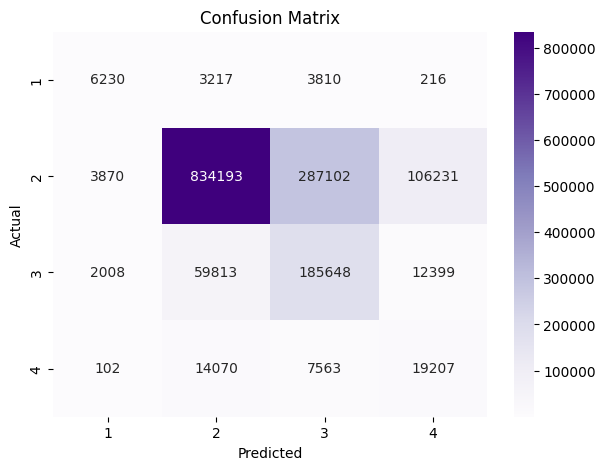

              precision    recall  f1-score   support

           1       0.51      0.46      0.49     13473
           2       0.92      0.68      0.78   1231396
           3       0.38      0.71      0.50    259868
           4       0.14      0.47      0.21     40942

    accuracy                           0.68   1545679
   macro avg       0.49      0.58      0.49   1545679
weighted avg       0.80      0.68      0.71   1545679



In [31]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Accuracy
acc = accuracy_score(y_test_shift, y_pred_final)
print(f"Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_shift, y_pred_final)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_test_shift, y_pred_final, target_names=['1','2','3','4']))

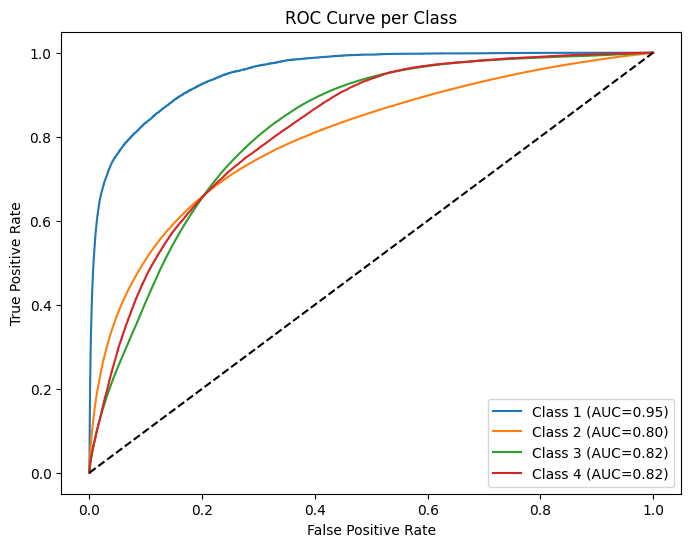

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


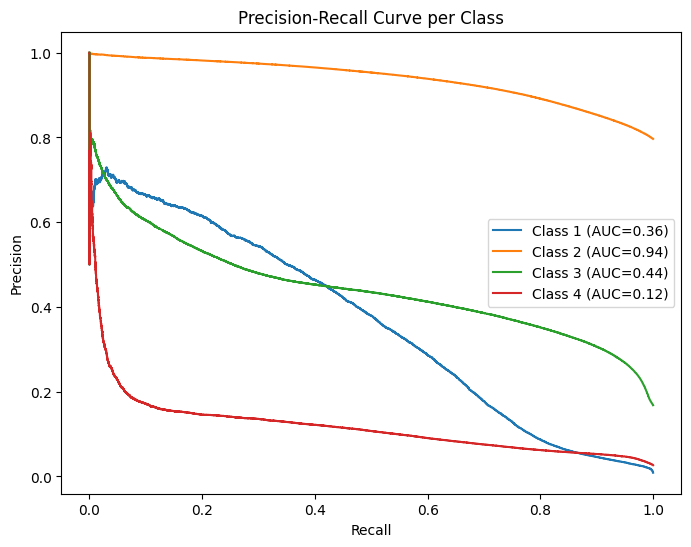

In [32]:
# ROC curves
plt.figure(figsize=(8,6))
for i in range(4):
    fpr, tpr, _ = roc_curve((y_test_shift==i).astype(int), y_test_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# Precision-Recall curves
plt.figure(figsize=(8,6))
for i in range(4):
    precision, recall, _ = precision_recall_curve((y_test_shift==i).astype(int), y_test_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {i+1} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()

In [15]:
# Downsample majority classes
train_bal = pd.concat([X_train_full, y_train_full], axis=1)
train_bal = behavior_sample(train_bal, target_class=2, max_samples=MAX_SAMPLES_PER_CLASS, upsample=False)
train_bal = behavior_sample(train_bal, target_class=3, max_samples=MAX_SAMPLES_PER_CLASS, upsample=False)

# Oversample minority classes
train_bal = behavior_sample(train_bal, target_class=1, max_samples=MAX_SAMPLES_PER_CLASS, upsample=True)
train_bal = behavior_sample(train_bal, target_class=4, max_samples=MAX_SAMPLES_PER_CLASS, upsample=True)

# Check class distribution
print("Class distribution after sampling:")
print(train_bal[TARGET_COL].value_counts())

Class distribution after sampling:
Severity
4    200000
1    200000
3    200000
2    200000
Name: count, dtype: int64


In [16]:
# Separate features and target
X_train_bal = train_bal.drop(TARGET_COL, axis=1)
y_train_bal = train_bal[TARGET_COL]

In [17]:
#  Target encoding
cat_cols = X_train_bal.select_dtypes(include='object').columns.tolist()
num_cols = X_train_bal.select_dtypes(include=np.number).columns.tolist()

if len(cat_cols) > 0:
    te = TargetEncoder(cols=cat_cols)
    X_train_bal[cat_cols] = te.fit_transform(X_train_bal[cat_cols], y_train_bal)
    X_test[cat_cols] = te.transform(X_test[cat_cols])

In [18]:
# Scale numeric features
scaler = StandardScaler()
X_train_bal[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [19]:
#  Shift labels for XGBoost
y_train_shift = (y_train_bal - 1).astype(int)
y_test_shift = (y_test - 1).astype(int)

#  Sample weights
weights = y_train_shift.map({0:5, 1:1, 2:2, 3:5}).to_numpy()  # emphasize minority classes

# Train XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train_bal, y_train_shift, sample_weight=weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=4, ...)

In [21]:
# Predict with probability thresholds
y_test_proba = xgb.predict_proba(X_test)
# Per-class probability thresholds
# Keys = class labels (1-based), values = probability thresholds
THRESHOLDS = {1:0.5, 2:0.6, 3:0.5, 4:0.4}
# Apply per-class thresholds
y_pred_thresh = np.zeros_like(y_test_shift)
for i in range(len(y_test_shift)):
    probs = y_test_proba[i]
    candidates = [j for j, p in enumerate(probs) if p >= THRESHOLDS[j+1]]
    y_pred_thresh[i] = max(candidates) if candidates else np.argmax(probs)

Accuracy: 0.5542


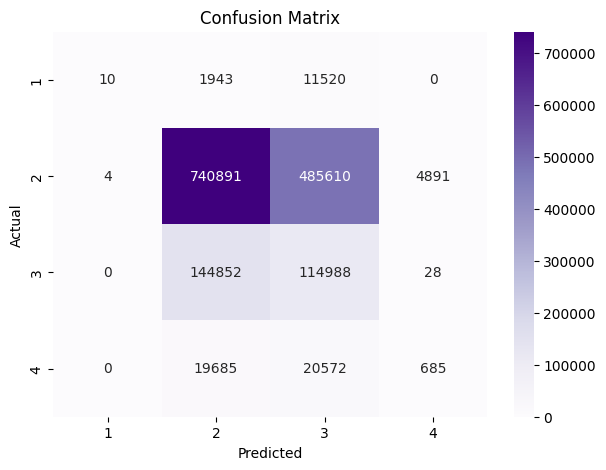

              precision    recall  f1-score   support

           1       0.71      0.00      0.00     13473
           2       0.82      0.60      0.69   1231396
           3       0.18      0.44      0.26    259868
           4       0.12      0.02      0.03     40942

    accuracy                           0.55   1545679
   macro avg       0.46      0.27      0.25   1545679
weighted avg       0.69      0.55      0.60   1545679



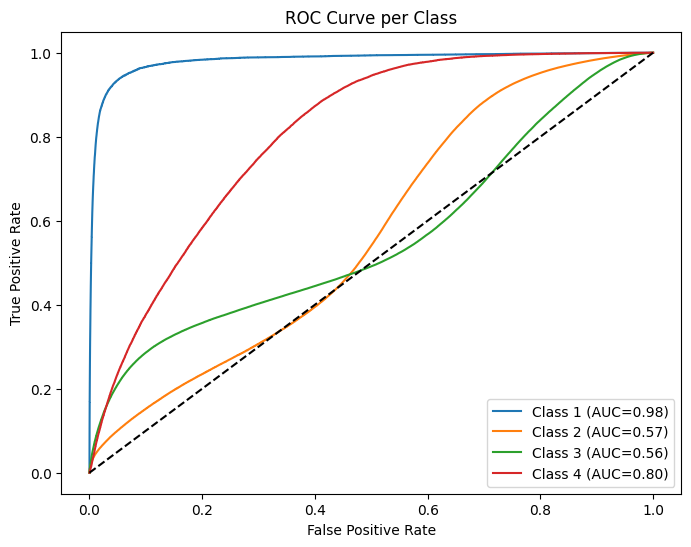

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


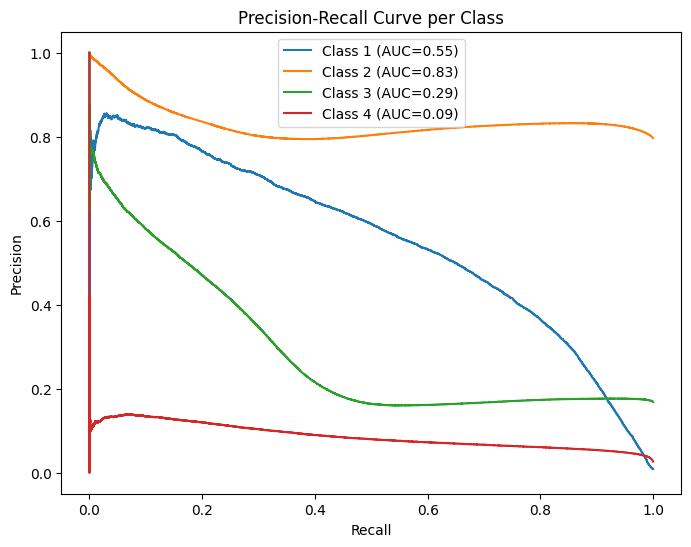

In [22]:
# Evaluate
# Accuracy
acc = accuracy_score(y_test_shift, y_pred_thresh)
print(f"Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_shift, y_pred_thresh)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_test_shift, y_pred_thresh, target_names=['1','2','3','4']))

# ROC curves
plt.figure(figsize=(8,6))
for i in range(4):
    fpr, tpr, _ = roc_curve((y_test_shift==i).astype(int), y_test_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# Precision-Recall curves
plt.figure(figsize=(8,6))
for i in range(4):
    precision, recall, _ = precision_recall_curve((y_test_shift==i).astype(int), y_test_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {i+1} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()